#### FINAL STATS

In [ ]:


from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import (
    PercentFormatter,
    FuncFormatter
)

from scipy.stats import wilcoxon

from statsmodels.stats.contingency_tables import (
    mcnemar
)


PROJECT_ROOT = Path("..").resolve()

FINAL_FOLDER = (
    PROJECT_ROOT
    / "Results"
    / "Final"
)

FIGURES_FOLDER = (
    FINAL_FOLDER
    / "figures"
)

FIGURES_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)


print("PROJECT_ROOT:", PROJECT_ROOT)
print("FINAL_FOLDER:", FINAL_FOLDER)
print("FIGURES_FOLDER:", FIGURES_FOLDER)

PROJECT_ROOT: C:\Users\srush\Desktop\Multi agent coordination
FINAL_FOLDER: C:\Users\srush\Desktop\Multi agent coordination\Results\Final
FIGURES_FOLDER: C:\Users\srush\Desktop\Multi agent coordination\Results\Final\figures


In [ ]:


quality = pd.read_csv(
    FINAL_FOLDER
    / "final_query_level_evaluation.csv"
)

final_summary = pd.read_csv(
    FINAL_FOLDER
    / "FINAL_SYSTEM_SUMMARY.csv"
)


print(
    "Query-level rows:",
    len(quality)
)

print(
    "Summary rows:",
    len(final_summary)
)

print("\nSystems:")

print(
    quality[
        "system"
    ].value_counts()
)


display(
    final_summary
)

Query-level rows: 180
Summary rows: 3

Systems:
system
Single Agent                        60
Multi-Agent Without Coordination    60
Coordinated Multi-Agent             60
Name: count, dtype: int64


,system,queries,recommendation_rate,mean_feature_satisfaction,grounded_recommendation_rate,partial_grounding_rate,hallucination_rate,correct_abstention_rate,mean_latency,median_latency,mean_tokens,total_tokens,mean_cost_usd,total_cost_usd
0,Single Agent,60,0.816667,0.778912,0.612245,0.102041,0.285714,0.666667,6.270542,5.53905,3374.583333,202475,0.000646,0.038733
1,Multi-Agent Without Coordination,60,0.933333,0.744048,0.678571,0.125000,0.196429,0.250000,6.676695,4.40220,1847.816667,110869,0.000365,0.021904
2,Coordinated Multi-Agent,60,0.716667,0.910853,0.837209,0.139535,0.023256,0.916667,4.789863,3.79430,1851.383333,111083,0.000368,0.022080


In [3]:
# =====================================================
# 03. CLEAN ARCHITECTURE LABELS
# =====================================================

DISPLAY_NAMES = {

    "Single Agent":
        "Single Agent",

    "Multi-Agent Without Coordination":
        "Uncoordinated MAS",

    "Coordinated Multi-Agent":
        "Coordinated MAS"
}


final_summary[
    "display_name"
] = (
    final_summary[
        "system"
    ]
    .map(
        DISPLAY_NAMES
    )
)


quality[
    "display_name"
] = (
    quality[
        "system"
    ]
    .map(
        DISPLAY_NAMES
    )
)

In [4]:
# =====================================================
# 04. DISSERTATION BAR-CHART FUNCTION
# =====================================================

def dissertation_bar_chart(
    dataframe,
    value_column,
    title,
    ylabel,
    filename,
    percentage=False,
    decimals=1,
    ylim=None
):

    fig, ax = plt.subplots(
        figsize=(8.5, 5.5)
    )


    x = np.arange(
        len(dataframe)
    )


    bars = ax.bar(
        x,
        dataframe[
            value_column
        ],
        width=0.62
    )


    # ---------------------------------------------
    # TITLE / AXES
    # ---------------------------------------------

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=16
    )


    ax.set_ylabel(
        ylabel,
        fontsize=11
    )


    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        dataframe[
            "display_name"
        ],
        fontsize=10
    )


    # ---------------------------------------------
    # Y AXIS
    # ---------------------------------------------

    if percentage:

        ax.yaxis.set_major_formatter(
            PercentFormatter(
                xmax=1,
                decimals=0
            )
        )


    if ylim is not None:

        ax.set_ylim(
            ylim
        )


    # ---------------------------------------------
    # GRID / CLEAN STYLE
    # ---------------------------------------------

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.30
    )

    ax.set_axisbelow(
        True
    )


    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )


    # ---------------------------------------------
    # VALUES ABOVE BARS
    # ---------------------------------------------

    values = dataframe[
        value_column
    ].tolist()


    if ylim is not None:

        height_range = (
            ylim[1]
            - ylim[0]
        )

    else:

        max_value = max(
            values
        )

        height_range = (
            max_value
            if max_value > 0
            else 1
        )


    offset = (
        height_range
        * 0.025
    )


    for bar, value in zip(
        bars,
        values
    ):

        if percentage:

            label = (
                f"{value:.{decimals}%}"
            )

        else:

            label = (
                f"{value:.{decimals}f}"
            )


        ax.text(
            bar.get_x()
            + bar.get_width() / 2,

            bar.get_height()
            + offset,

            label,

            ha="center",
            va="bottom",

            fontsize=10,
            fontweight="bold"
        )


    plt.tight_layout()


    output_path = (
        FIGURES_FOLDER
        / filename
    )


    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    print(
        "Saved:",
        output_path
    )

FEATURE SATIFSAFACTION

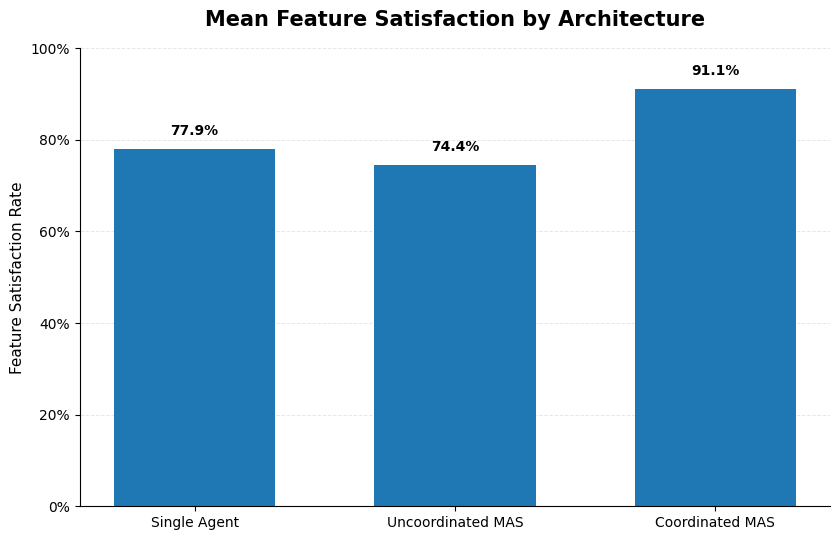

Saved: C:\Users\srush\Desktop\Multi agent coordination\Results\Final\figures\01_feature_satisfaction.png


In [5]:
# =====================================================
# 05. FEATURE SATISFACTION
# =====================================================

dissertation_bar_chart(

    dataframe=final_summary,

    value_column=(
        "mean_feature_satisfaction"
    ),

    title=(
        "Mean Feature Satisfaction by Architecture"
    ),

    ylabel=(
        "Feature Satisfaction Rate"
    ),

    filename=(
        "01_feature_satisfaction.png"
    ),

    percentage=True,

    decimals=1,

    ylim=(
        0,
        1
    )
)

GROUNDED REC RATE

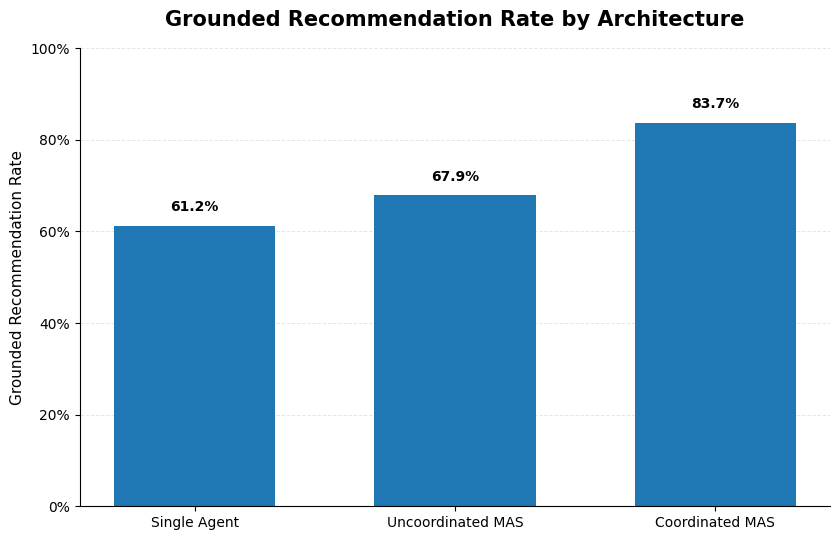

Saved: C:\Users\srush\Desktop\Multi agent coordination\Results\Final\figures\02_grounded_recommendation_rate.png


In [6]:
# =====================================================
# 06. GROUNDED RECOMMENDATION RATE
# =====================================================

dissertation_bar_chart(

    dataframe=final_summary,

    value_column=(
        "grounded_recommendation_rate"
    ),

    title=(
        "Grounded Recommendation Rate by Architecture"
    ),

    ylabel=(
        "Grounded Recommendation Rate"
    ),

    filename=(
        "02_grounded_recommendation_rate.png"
    ),

    percentage=True,

    decimals=1,

    ylim=(
        0,
        1
    )
)

HALLUCINATION/UNSUPOORTED REC RATE

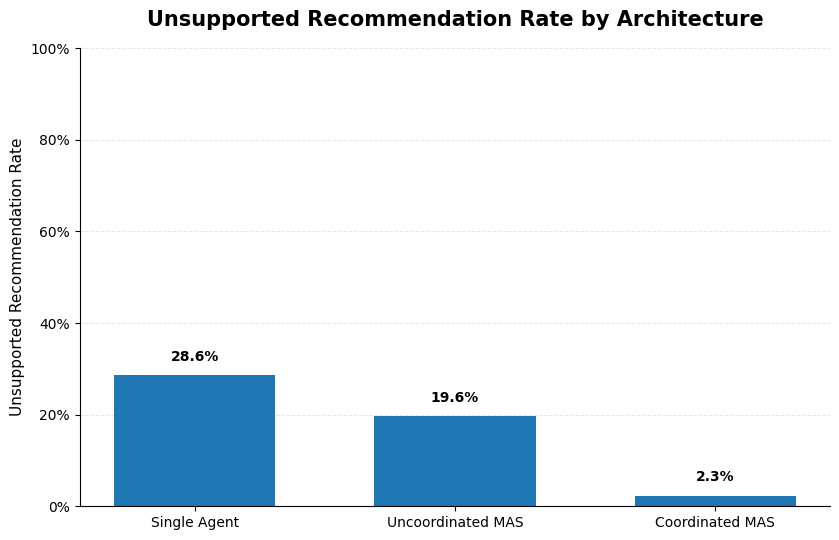

Saved: C:\Users\srush\Desktop\Multi agent coordination\Results\Final\figures\03_unsupported_recommendation_rate.png


In [7]:
# =====================================================
# 07. UNSUPPORTED RECOMMENDATION RATE
# =====================================================

dissertation_bar_chart(

    dataframe=final_summary,

    value_column=(
        "hallucination_rate"
    ),

    title=(
        "Unsupported Recommendation Rate by Architecture"
    ),

    ylabel=(
        "Unsupported Recommendation Rate"
    ),

    filename=(
        "03_unsupported_recommendation_rate.png"
    ),

    percentage=True,

    decimals=1,

    ylim=(
        0,
        1
    )
)

CORRECT ABSETNTION RATE

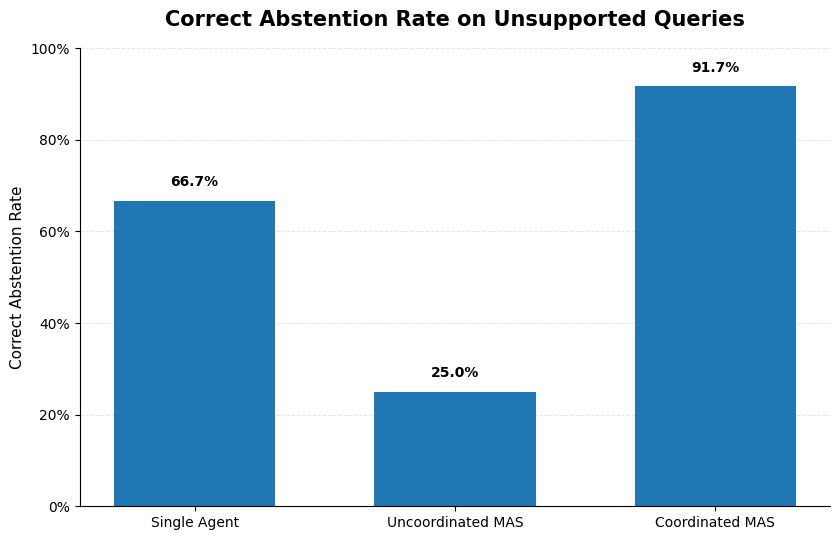

Saved: C:\Users\srush\Desktop\Multi agent coordination\Results\Final\figures\04_correct_abstention_rate.png


In [8]:
# =====================================================
# 08. CORRECT ABSTENTION RATE
# =====================================================

dissertation_bar_chart(

    dataframe=final_summary,

    value_column=(
        "correct_abstention_rate"
    ),

    title=(
        "Correct Abstention Rate on Unsupported Queries"
    ),

    ylabel=(
        "Correct Abstention Rate"
    ),

    filename=(
        "04_correct_abstention_rate.png"
    ),

    percentage=True,

    decimals=1,

    ylim=(
        0,
        1
    )
)

RECOMMENDATION COVERAGE

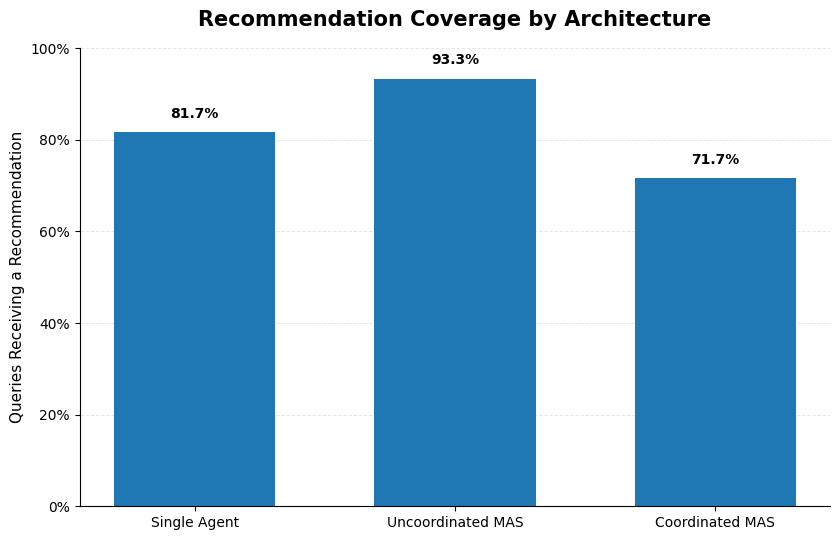

Saved: C:\Users\srush\Desktop\Multi agent coordination\Results\Final\figures\05_recommendation_coverage.png


In [9]:
# =====================================================
# 09. RECOMMENDATION COVERAGE
# =====================================================

dissertation_bar_chart(

    dataframe=final_summary,

    value_column=(
        "recommendation_rate"
    ),

    title=(
        "Recommendation Coverage by Architecture"
    ),

    ylabel=(
        "Queries Receiving a Recommendation"
    ),

    filename=(
        "05_recommendation_coverage.png"
    ),

    percentage=True,

    decimals=1,

    ylim=(
        0,
        1
    )
)

TOKEN USAGE

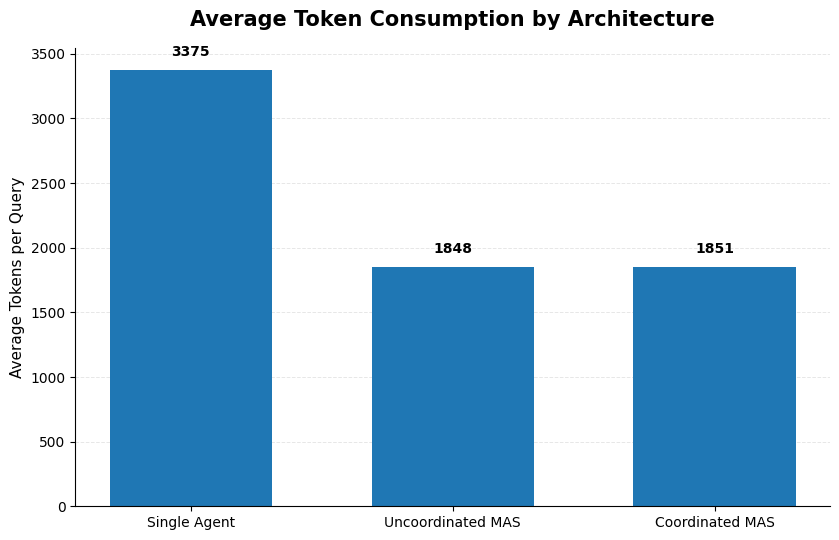

Saved: C:\Users\srush\Desktop\Multi agent coordination\Results\Final\figures\06_average_token_consumption.png


In [10]:
# =====================================================
# 10. TOKEN CONSUMPTION
# =====================================================

dissertation_bar_chart(

    dataframe=final_summary,

    value_column=(
        "mean_tokens"
    ),

    title=(
        "Average Token Consumption by Architecture"
    ),

    ylabel=(
        "Average Tokens per Query"
    ),

    filename=(
        "06_average_token_consumption.png"
    ),

    percentage=False,

    decimals=0,

    ylim=None
)

LATENCY

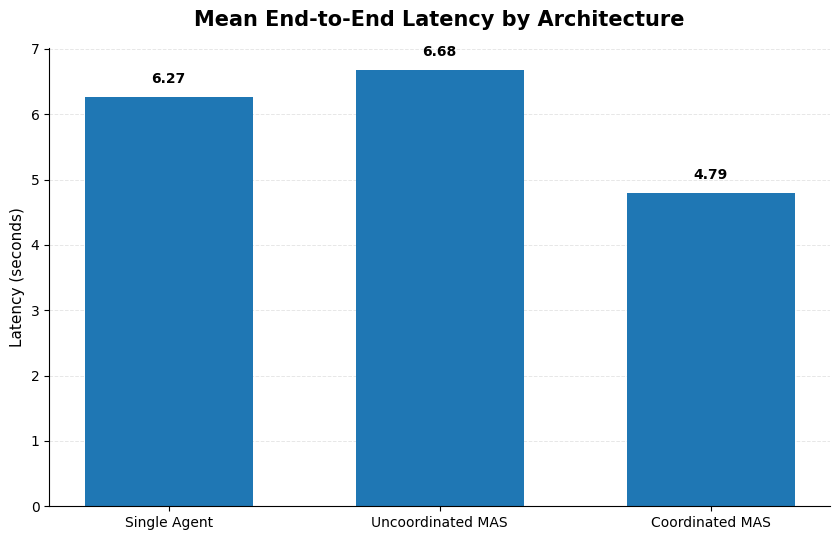

Saved: C:\Users\srush\Desktop\Multi agent coordination\Results\Final\figures\07_mean_latency.png


In [11]:
# =====================================================
# 11. MEAN LATENCY
# =====================================================

dissertation_bar_chart(

    dataframe=final_summary,

    value_column=(
        "mean_latency"
    ),

    title=(
        "Mean End-to-End Latency by Architecture"
    ),

    ylabel=(
        "Latency (seconds)"
    ),

    filename=(
        "07_mean_latency.png"
    ),

    percentage=False,

    decimals=2,

    ylim=None
)

COST PER QUERY


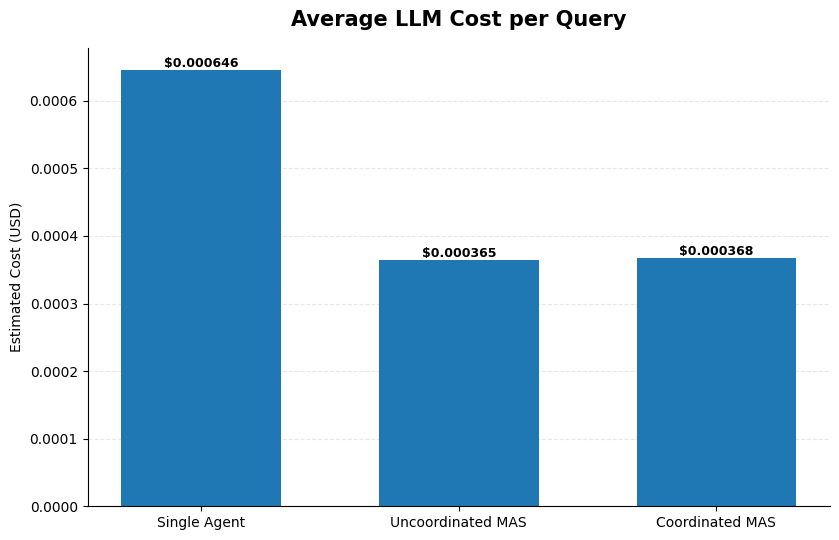

In [12]:
# =====================================================
# 12. AVERAGE COST PER QUERY
# =====================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)


bars = ax.bar(
    final_summary[
        "display_name"
    ],
    final_summary[
        "mean_cost_usd"
    ],
    width=0.62
)


ax.set_title(
    "Average LLM Cost per Query",
    fontsize=15,
    fontweight="bold",
    pad=16
)


ax.set_ylabel(
    "Estimated Cost (USD)"
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(
    True
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


for bar, value in zip(
    bars,
    final_summary[
        "mean_cost_usd"
    ]
):

    ax.text(

        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        f"${value:.6f}",

        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )


plt.tight_layout()


plt.savefig(
    FIGURES_FOLDER
    / "08_average_cost_per_query.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

PRECISION@5 AND RECALL@5

In [13]:
# =====================================================
# 13. LOAD RETRIEVAL PERFORMANCE
# =====================================================

precision_recall = pd.read_csv(
    FINAL_FOLDER
    / "final_precision_recall_summary.csv"
)


precision_recall[
    "display_name"
] = (
    precision_recall[
        "system"
    ]
    .map(
        DISPLAY_NAMES
    )
)


display(
    precision_recall
)

,system,mean_precision_at_5,mean_recall_at_5,display_name
0,Coordinated Multi-Agent,0.48,0.196668,Coordinated MAS
1,Multi-Agent Without Coordination,0.48,0.196668,Uncoordinated MAS
2,Single Agent,0.32,0.119882,Single Agent


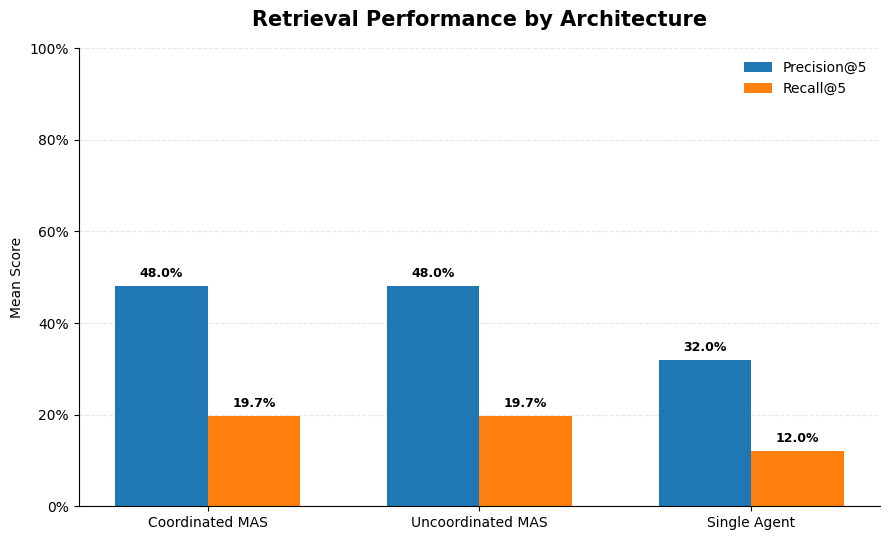

In [14]:
# =====================================================
# 14. PRECISION@5 AND RECALL@5
# =====================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)


x = np.arange(
    len(
        precision_recall
    )
)

width = 0.34


precision_bars = ax.bar(

    x - width / 2,

    precision_recall[
        "mean_precision_at_5"
    ],

    width,

    label="Precision@5"
)


recall_bars = ax.bar(

    x + width / 2,

    precision_recall[
        "mean_recall_at_5"
    ],

    width,

    label="Recall@5"
)


ax.set_title(
    "Retrieval Performance by Architecture",
    fontsize=15,
    fontweight="bold",
    pad=16
)


ax.set_ylabel(
    "Mean Score"
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    precision_recall[
        "display_name"
    ]
)


ax.set_ylim(
    0,
    1
)


ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=1
    )
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)


ax.set_axisbelow(
    True
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


ax.legend(
    frameon=False
)


for bars in [
    precision_bars,
    recall_bars
]:

    for bar in bars:

        value = (
            bar.get_height()
        )

        ax.text(

            bar.get_x()
            + bar.get_width() / 2,

            value
            + 0.02,

            f"{value:.1%}",

            ha="center",
            fontsize=9,
            fontweight="bold"
        )


plt.tight_layout()


plt.savefig(
    FIGURES_FOLDER
    / "09_precision_recall_at_5.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

SCALABILITY

In [15]:
# =====================================================
# 15. LOAD SCALABILITY RESULTS
# =====================================================

no_coord_scalability = pd.read_csv(
    FINAL_FOLDER
    / "no_coord_scalability.csv"
)


coord_scalability = pd.read_csv(
    FINAL_FOLDER
    / "coordinated_scalability.csv"
)


scalability = pd.concat(
    [
        no_coord_scalability,
        coord_scalability
    ],
    ignore_index=True
)


scalability_summary = (

    scalability

    .groupby(
        [
            "system",
            "retrieval_k"
        ],
        as_index=False
    )

    .agg(

        mean_latency=(
            "latency",
            "mean"
        ),

        std_latency=(
            "latency",
            "std"
        ),

        mean_tokens=(
            "tokens",
            "mean"
        ),

        std_tokens=(
            "tokens",
            "std"
        )
    )
)


scalability_summary[
    "display_name"
] = (
    scalability_summary[
        "system"
    ]
    .map(
        DISPLAY_NAMES
    )
)


display(
    scalability_summary
)

,system,retrieval_k,mean_latency,std_latency,mean_tokens,std_tokens,display_name
0,Coordinated Multi-Agent,5,4.131550,0.603951,1650.625,129.525439,Coordinated MAS
1,Coordinated Multi-Agent,10,4.080650,0.395685,1638.500,131.657564,Coordinated MAS
2,Coordinated Multi-Agent,20,6.258025,1.796878,1969.500,393.117939,Coordinated MAS
3,Coordinated Multi-Agent,30,6.496462,2.823595,2015.375,451.632258,Coordinated MAS
4,Multi-Agent Without Coordination,5,3.987600,0.647407,1654.250,124.983142,Uncoordinated MAS
5,Multi-Agent Without Coordination,10,3.497663,0.268361,1644.125,134.728762,Uncoordinated MAS
6,Multi-Agent Without Coordination,20,5.630175,3.101755,2017.250,481.862088,Uncoordinated MAS
7,Multi-Agent Without Coordination,30,5.169837,1.992185,2000.750,431.849097,Uncoordinated MAS


SCALABILITY LATENCY PLOT

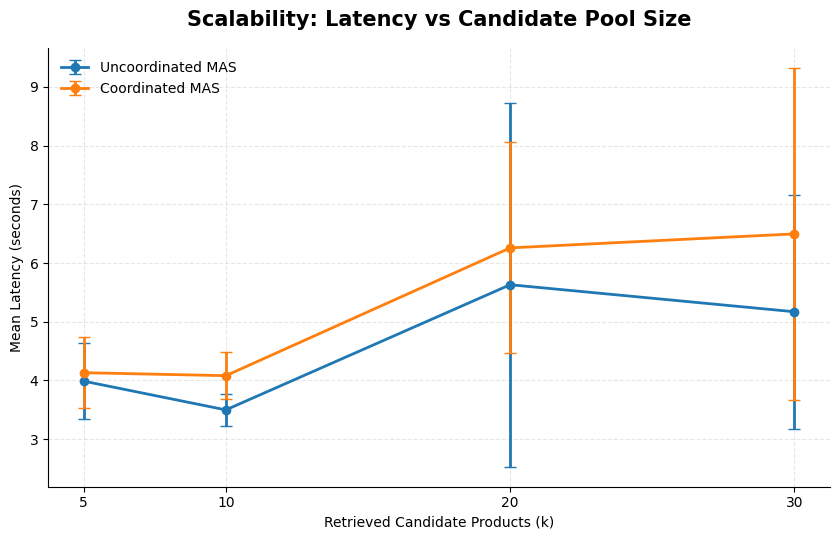

In [16]:
# =====================================================
# 16. SCALABILITY — LATENCY
# =====================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)


for system_name in [
    "Uncoordinated MAS",
    "Coordinated MAS"
]:

    system_df = (
        scalability_summary[
            scalability_summary[
                "display_name"
            ]
            == system_name
        ]
        .sort_values(
            "retrieval_k"
        )
    )


    ax.errorbar(

        system_df[
            "retrieval_k"
        ],

        system_df[
            "mean_latency"
        ],

        yerr=system_df[
            "std_latency"
        ],

        marker="o",

        linewidth=2,

        capsize=4,

        label=system_name
    )


ax.set_title(
    "Scalability: Latency vs Candidate Pool Size",
    fontsize=15,
    fontweight="bold",
    pad=16
)


ax.set_xlabel(
    "Retrieved Candidate Products (k)"
)


ax.set_ylabel(
    "Mean Latency (seconds)"
)


ax.set_xticks(
    [
        5,
        10,
        20,
        30
    ]
)


ax.grid(
    linestyle="--",
    alpha=0.3
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


ax.legend(
    frameon=False
)


plt.tight_layout()


plt.savefig(
    FIGURES_FOLDER
    / "10_scalability_latency.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

SCALABILITY TOKENS

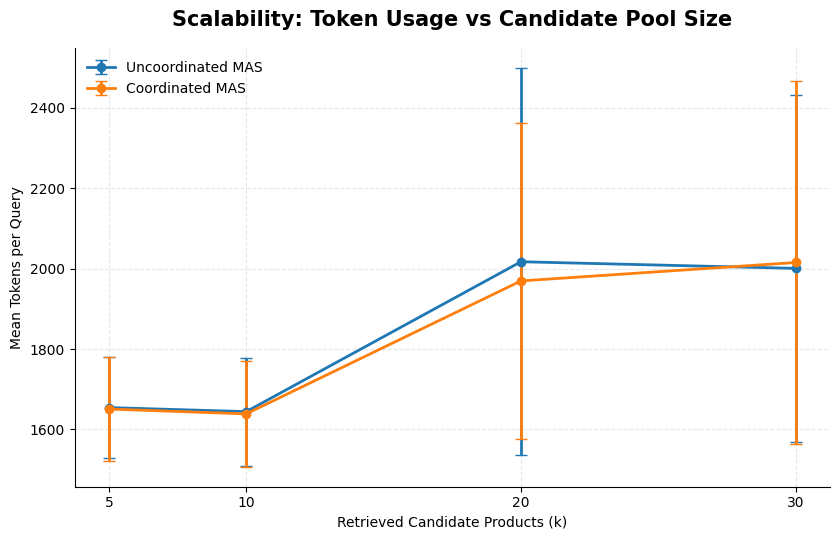

In [17]:
# =====================================================
# 17. SCALABILITY — TOKENS
# =====================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)


for system_name in [
    "Uncoordinated MAS",
    "Coordinated MAS"
]:

    system_df = (
        scalability_summary[
            scalability_summary[
                "display_name"
            ]
            == system_name
        ]
        .sort_values(
            "retrieval_k"
        )
    )


    ax.errorbar(

        system_df[
            "retrieval_k"
        ],

        system_df[
            "mean_tokens"
        ],

        yerr=system_df[
            "std_tokens"
        ],

        marker="o",

        linewidth=2,

        capsize=4,

        label=system_name
    )


ax.set_title(
    "Scalability: Token Usage vs Candidate Pool Size",
    fontsize=15,
    fontweight="bold",
    pad=16
)


ax.set_xlabel(
    "Retrieved Candidate Products (k)"
)


ax.set_ylabel(
    "Mean Tokens per Query"
)


ax.set_xticks(
    [
        5,
        10,
        20,
        30
    ]
)


ax.grid(
    linestyle="--",
    alpha=0.3
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


ax.legend(
    frameon=False
)


plt.tight_layout()


plt.savefig(
    FIGURES_FOLDER
    / "11_scalability_tokens.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

MAIN RECOMMENDATION QULIATY COMPARISON

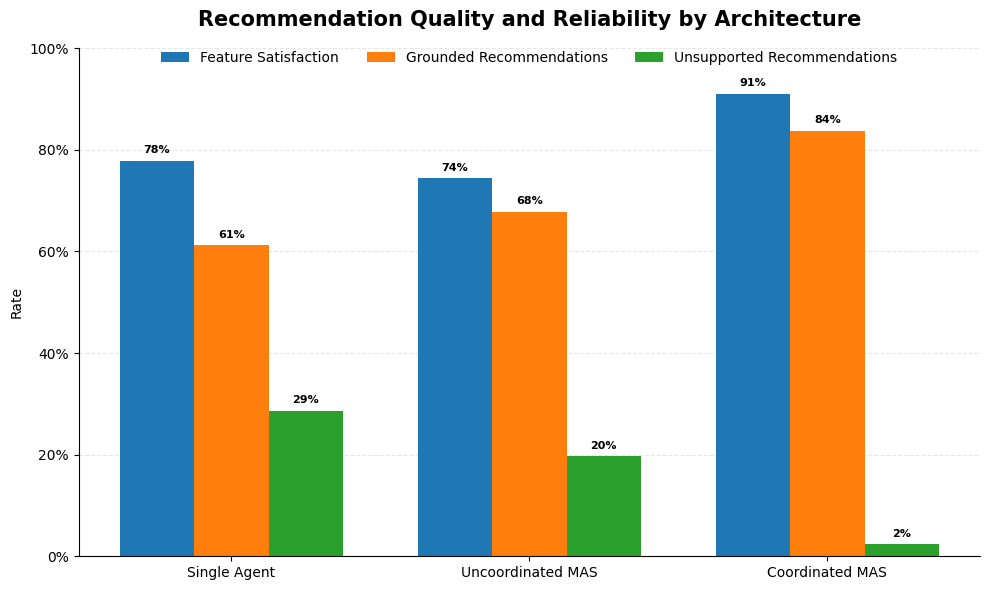

In [18]:
# =====================================================
# 18. MAIN RECOMMENDATION QUALITY COMPARISON
# =====================================================

quality_plot = (
    final_summary[
        [
            "display_name",
            "mean_feature_satisfaction",
            "grounded_recommendation_rate",
            "hallucination_rate"
        ]
    ]
    .copy()
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


x = np.arange(
    len(
        quality_plot
    )
)


width = 0.25


bars1 = ax.bar(

    x - width,

    quality_plot[
        "mean_feature_satisfaction"
    ],

    width,

    label="Feature Satisfaction"
)


bars2 = ax.bar(

    x,

    quality_plot[
        "grounded_recommendation_rate"
    ],

    width,

    label="Grounded Recommendations"
)


bars3 = ax.bar(

    x + width,

    quality_plot[
        "hallucination_rate"
    ],

    width,

    label="Unsupported Recommendations"
)


ax.set_title(
    "Recommendation Quality and Reliability by Architecture",
    fontsize=15,
    fontweight="bold",
    pad=16
)


ax.set_ylabel(
    "Rate"
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    quality_plot[
        "display_name"
    ]
)


ax.set_ylim(
    0,
    1
)


ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=1
    )
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)


ax.set_axisbelow(
    True
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        1.02
    )
)


for bars in [
    bars1,
    bars2,
    bars3
]:

    for bar in bars:

        value = (
            bar.get_height()
        )

        ax.text(

            bar.get_x()
            + bar.get_width() / 2,

            value
            + 0.015,

            f"{value:.0%}",

            ha="center",
            fontsize=8,
            fontweight="bold"
        )


plt.tight_layout()


plt.savefig(
    FIGURES_FOLDER
    / "12_main_quality_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [19]:
# =====================================================
# RECREATE WILCOXON STATISTICAL RESULTS
# =====================================================

from scipy.stats import wilcoxon

import pandas as pd
import numpy as np


def run_wilcoxon_test(
    dataframe,
    metric,
    system_a,
    system_b
):

    # Get values for System A
    a = (
        dataframe[
            dataframe["system"] == system_a
        ][
            ["test_id", metric]
        ]
        .rename(
            columns={
                metric: "value_a"
            }
        )
    )

    # Get values for System B
    b = (
        dataframe[
            dataframe["system"] == system_b
        ][
            ["test_id", metric]
        ]
        .rename(
            columns={
                metric: "value_b"
            }
        )
    )

    # Pair results using test_id
    paired = (
        a.merge(
            b,
            on="test_id"
        )
        .dropna()
    )

    # Differences
    differences = (
        paired["value_a"]
        - paired["value_b"]
    )

    # If every difference is zero,
    # Wilcoxon cannot be calculated normally
    if np.allclose(
        differences,
        0
    ):

        statistic = 0.0
        p_value = 1.0

    else:

        result = wilcoxon(
            paired["value_a"],
            paired["value_b"],
            alternative="two-sided"
        )

        statistic = float(
            result.statistic
        )

        p_value = float(
            result.pvalue
        )


    return {

        "metric":
            metric,

        "system_a":
            system_a,

        "system_b":
            system_b,

        "n":
            len(paired),

        "mean_a":
            paired["value_a"].mean(),

        "mean_b":
            paired["value_b"].mean(),

        "mean_difference":
            (
                paired["value_b"].mean()
                - paired["value_a"].mean()
            ),

        "statistic":
            statistic,

        "p_value":
            p_value
    }

In [20]:
# =====================================================
# SYSTEM COMPARISONS
# =====================================================

comparisons = [

    (
        "Single Agent",
        "Coordinated Multi-Agent"
    ),

    (
        "Multi-Agent Without Coordination",
        "Coordinated Multi-Agent"
    )
]

In [21]:
print(
    quality.columns.tolist()
)

['system', 'test_id', 'category', 'user_query', 'expected_outcome', 'has_recommendation', 'recommended_asin', 'product_type_match', 'brand_match', 'budget_match', 'feature_match_ratio', 'feature_status', 'support_level', 'correct_abstention', 'incorrect_abstention', 'total_latency', 'total_tokens', 'estimated_cost_usd', 'display_name']


In [22]:
possible_metrics = [
    "feature_match_ratio",
    "total_latency",
    "latency",
    "latency_seconds",
    "total_tokens",
    "tokens"
]

for column in possible_metrics:

    if column in quality.columns:

        print(
            "FOUND:",
            column
        )

FOUND: feature_match_ratio
FOUND: total_latency
FOUND: total_tokens


In [23]:
metrics = [
    "feature_match_ratio",
    "total_latency",
    "total_tokens"
]

In [24]:
# =====================================================
# RUN FINAL WILCOXON TESTS
# =====================================================

wilcoxon_rows = []


for system_a, system_b in comparisons:

    for metric in metrics:

        result = run_wilcoxon_test(
            dataframe=quality,
            metric=metric,
            system_a=system_a,
            system_b=system_b
        )

        wilcoxon_rows.append(
            result
        )


statistical_results = pd.DataFrame(
    wilcoxon_rows
)


statistical_results[
    "significant_at_0_05"
] = (
    statistical_results[
        "p_value"
    ] < 0.05
)


display(
    statistical_results
)

,metric,system_a,system_b,n,mean_a,mean_b,mean_difference,statistic,p_value,significant_at_0_05
0,feature_match_ratio,Single Agent,Coordinated Multi-Agent,40,0.854167,0.916667,0.062500,0.0,1.024704e-01,False
1,total_latency,Single Agent,Coordinated Multi-Agent,60,6.270542,4.789863,-1.480678,592.0,1.741637e-02,True
2,total_tokens,Single Agent,Coordinated Multi-Agent,60,3374.583333,1851.383333,-1523.200000,14.0,3.293684e-11,True
3,feature_match_ratio,Multi-Agent Without Coordination,Coordinated Multi-Agent,43,0.852713,0.910853,0.058140,0.0,5.878172e-02,False
4,total_latency,Multi-Agent Without Coordination,Coordinated Multi-Agent,60,6.676695,4.789863,-1.886832,456.0,7.275642e-04,True
5,total_tokens,Multi-Agent Without Coordination,Coordinated Multi-Agent,60,1847.816667,1851.383333,3.566667,543.5,8.282075e-01,False


In [25]:
statistical_results.to_csv(
    FINAL_FOLDER
    / "wilcoxon_results.csv",
    index=False
)

print(
    "Saved wilcoxon_results.csv"
)

Saved wilcoxon_results.csv


McNEMAR 

In [26]:
# =====================================================
# CHECK COLUMNS NEEDED FOR MCNEMAR
# =====================================================

print(
    quality.columns.tolist()
)

['system', 'test_id', 'category', 'user_query', 'expected_outcome', 'has_recommendation', 'recommended_asin', 'product_type_match', 'brand_match', 'budget_match', 'feature_match_ratio', 'feature_status', 'support_level', 'correct_abstention', 'incorrect_abstention', 'total_latency', 'total_tokens', 'estimated_cost_usd', 'display_name']


In [27]:
possible_columns = [
    "support_level",
    "is_grounded",
    "is_hallucinated",
    "correct_abstention",
    "expected_outcome",
    "recommendation_made"
]

for column in possible_columns:

    print(
        column,
        "->",
        column in quality.columns
    )

support_level -> True
is_grounded -> False
is_hallucinated -> False
correct_abstention -> True
expected_outcome -> True
recommendation_made -> False


In [28]:
# =====================================================
# MCNEMAR STEP 1 — CREATE BINARY OUTCOMES
# =====================================================

quality["is_grounded"] = (
    quality["support_level"]
    == "grounded"
)

quality["is_hallucinated"] = (
    quality["support_level"]
    == "unsupported"
)

quality["correct_abstention"] = (
    quality["correct_abstention"]
    .fillna(False)
    .astype(bool)
)


print("Binary outcome columns created.\n")

print(
    quality[
        [
            "system",
            "test_id",
            "expected_outcome",
            "support_level",
            "is_grounded",
            "is_hallucinated",
            "correct_abstention"
        ]
    ].head(10)
)

Binary outcome columns created.

         system  test_id expected_outcome support_level  is_grounded  \
0  Single Agent        1            match      grounded         True   
1  Single Agent        2            match      grounded         True   
2  Single Agent        3            match      grounded         True   
3  Single Agent        4            match      grounded         True   
4  Single Agent        5            match   unsupported        False   
5  Single Agent        6            match      grounded         True   
6  Single Agent        7            match      grounded         True   
7  Single Agent        8            match      grounded         True   
8  Single Agent        9            match      grounded         True   
9  Single Agent       10            match   unsupported        False   

   is_hallucinated  correct_abstention  
0            False               False  
1            False               False  
2            False               False  
3         

In [29]:
# =====================================================
# MCNEMAR STEP 2 — CHECK OUTCOME COUNTS
# =====================================================

print("\nGROUNDED COUNTS")
print(
    pd.crosstab(
        quality["system"],
        quality["is_grounded"]
    )
)


print("\nHALLUCINATION COUNTS")
print(
    pd.crosstab(
        quality["system"],
        quality["is_hallucinated"]
    )
)


print("\nCORRECT ABSTENTION COUNTS")
print(
    pd.crosstab(
        quality["system"],
        quality["correct_abstention"]
    )
)


GROUNDED COUNTS
is_grounded                       False  True 
system                                        
Coordinated Multi-Agent              24     36
Multi-Agent Without Coordination     22     38
Single Agent                         30     30

HALLUCINATION COUNTS
is_hallucinated                   False  True 
system                                        
Coordinated Multi-Agent              59      1
Multi-Agent Without Coordination     49     11
Single Agent                         46     14

CORRECT ABSTENTION COUNTS
correct_abstention                False  True 
system                                        
Coordinated Multi-Agent              49     11
Multi-Agent Without Coordination     57      3
Single Agent                         52      8


In [30]:
# =====================================================
# MCNEMAR STEP 3 — TEST FUNCTION
# =====================================================

from statsmodels.stats.contingency_tables import (
    mcnemar
)


def run_mcnemar_test(
    dataframe,
    outcome_column,
    system_a,
    system_b
):

    a = (
        dataframe[
            dataframe["system"] == system_a
        ][
            [
                "test_id",
                outcome_column
            ]
        ]
        .rename(
            columns={
                outcome_column:
                    "outcome_a"
            }
        )
    )


    b = (
        dataframe[
            dataframe["system"] == system_b
        ][
            [
                "test_id",
                outcome_column
            ]
        ]
        .rename(
            columns={
                outcome_column:
                    "outcome_b"
            }
        )
    )


    paired = (
        a.merge(
            b,
            on="test_id"
        )
        .dropna()
    )


    table = pd.crosstab(
        paired["outcome_a"],
        paired["outcome_b"]
    )


    table = table.reindex(
        index=[
            False,
            True
        ],
        columns=[
            False,
            True
        ],
        fill_value=0
    )


    result = mcnemar(
        table.values,
        exact=True
    )


    return {

        "metric":
            outcome_column,

        "system_a":
            system_a,

        "system_b":
            system_b,

        "n":
            len(paired),

        "both_false":
            int(table.loc[False, False]),

        "a_false_b_true":
            int(table.loc[False, True]),

        "a_true_b_false":
            int(table.loc[True, False]),

        "both_true":
            int(table.loc[True, True]),

        "statistic":
            float(result.statistic),

        "p_value":
            float(result.pvalue)
    }

In [31]:
# =====================================================
# MCNEMAR STEP 4 — GROUNDING + HALLUCINATION
# =====================================================

comparisons = [

    (
        "Single Agent",
        "Coordinated Multi-Agent"
    ),

    (
        "Multi-Agent Without Coordination",
        "Coordinated Multi-Agent"
    )
]


mcnemar_rows = []


for system_a, system_b in comparisons:

    for metric in [
        "is_grounded",
        "is_hallucinated"
    ]:

        result = run_mcnemar_test(
            dataframe=quality,
            outcome_column=metric,
            system_a=system_a,
            system_b=system_b
        )

        mcnemar_rows.append(
            result
        )


mcnemar_df = pd.DataFrame(
    mcnemar_rows
)


mcnemar_df[
    "significant_at_0_05"
] = (
    mcnemar_df[
        "p_value"
    ] < 0.05
)


display(
    mcnemar_df
)

,metric,system_a,system_b,n,both_false,a_false_b_true,a_true_b_false,both_true,statistic,p_value,significant_at_0_05
0,is_grounded,Single Agent,Coordinated Multi-Agent,60,20,10,4,26,4.0,0.179565,False
1,is_hallucinated,Single Agent,Coordinated Multi-Agent,60,46,0,13,1,0.0,0.000244,True
2,is_grounded,Multi-Agent Without Coordination,Coordinated Multi-Agent,60,19,3,5,33,3.0,0.726562,False
3,is_hallucinated,Multi-Agent Without Coordination,Coordinated Multi-Agent,60,49,0,10,1,0.0,0.001953,True


In [32]:
# =====================================================
# MCNEMAR STEP 5A — CHECK EXPECTED OUTCOMES
# =====================================================

print(
    quality[
        "expected_outcome"
    ].value_counts(
        dropna=False
    )
)

expected_outcome
match       144
no_match     36
Name: count, dtype: int64


In [33]:
# =====================================================
# MCNEMAR STEP 5B — CORRECT ABSTENTION
# =====================================================

no_match_quality = (
    quality[
        quality["expected_outcome"]
        == "no_match"
    ]
    .copy()
)


print(
    "Total no-match rows:",
    len(no_match_quality)
)


print("\nRows per architecture:")

print(
    no_match_quality[
        "system"
    ].value_counts()
)


print("\nCorrect abstention counts:")

print(
    pd.crosstab(
        no_match_quality["system"],
        no_match_quality["correct_abstention"]
    )
)

Total no-match rows: 36

Rows per architecture:
system
Single Agent                        12
Multi-Agent Without Coordination    12
Coordinated Multi-Agent             12
Name: count, dtype: int64

Correct abstention counts:
correct_abstention                False  True 
system                                        
Coordinated Multi-Agent               1     11
Multi-Agent Without Coordination      9      3
Single Agent                          4      8


In [34]:
# =====================================================
# MCNEMAR STEP 5C — ABSTENTION COMPARISONS
# =====================================================

abstention_rows = []


for system_a, system_b in comparisons:

    result = run_mcnemar_test(
        dataframe=no_match_quality,
        outcome_column="correct_abstention",
        system_a=system_a,
        system_b=system_b
    )

    abstention_rows.append(
        result
    )


abstention_mcnemar_df = pd.DataFrame(
    abstention_rows
)


abstention_mcnemar_df[
    "significant_at_0_05"
] = (
    abstention_mcnemar_df[
        "p_value"
    ] < 0.05
)


display(
    abstention_mcnemar_df
)

,metric,system_a,system_b,n,both_false,a_false_b_true,a_true_b_false,both_true,statistic,p_value,significant_at_0_05
0,correct_abstention,Single Agent,Coordinated Multi-Agent,12,0,4,1,7,1.0,0.375000,False
1,correct_abstention,Multi-Agent Without Coordination,Coordinated Multi-Agent,12,1,8,0,3,0.0,0.007812,True


In [35]:
# =====================================================
# SAVE MCNEMAR RESULTS
# =====================================================

mcnemar_df.to_csv(
    FINAL_FOLDER
    / "mcnemar_grounding_hallucination.csv",
    index=False
)


abstention_mcnemar_df.to_csv(
    FINAL_FOLDER
    / "mcnemar_abstention.csv",
    index=False
)


print(
    "McNemar results saved successfully."
)

McNemar results saved successfully.


EFFECT SIZE

In [36]:
# =====================================================
# EFFECT SIZE STEP 1
# MATCHED-PAIRS RANK-BISERIAL CORRELATION
# =====================================================

from scipy.stats import rankdata


def paired_rank_biserial(
    dataframe,
    metric,
    system_a,
    system_b
):

    a = (
        dataframe[
            dataframe["system"] == system_a
        ][["test_id", metric]]
        .rename(
            columns={
                metric: "value_a"
            }
        )
    )

    b = (
        dataframe[
            dataframe["system"] == system_b
        ][["test_id", metric]]
        .rename(
            columns={
                metric: "value_b"
            }
        )
    )

    paired = (
        a.merge(
            b,
            on="test_id"
        )
        .dropna()
    )

    # Positive difference means System B > System A
    differences = (
        paired["value_b"]
        - paired["value_a"]
    )

    # Wilcoxon excludes zero differences
    differences = differences[
        differences != 0
    ]

    if len(differences) == 0:
        return 0.0

    ranks = rankdata(
        np.abs(differences)
    )

    positive_rank_sum = (
        ranks[
            differences > 0
        ].sum()
    )

    negative_rank_sum = (
        ranks[
            differences < 0
        ].sum()
    )

    total_rank_sum = (
        positive_rank_sum
        + negative_rank_sum
    )

    rank_biserial = (
        positive_rank_sum
        - negative_rank_sum
    ) / total_rank_sum

    return float(
        rank_biserial
    )

In [37]:
# =====================================================
# EFFECT SIZE STEP 2
# RUN ALL COMPARISONS
# =====================================================

effect_rows = []


metrics = [
    "feature_match_ratio",
    "total_latency",
    "total_tokens"
]


for system_a, system_b in comparisons:

    for metric in metrics:

        effect_size = paired_rank_biserial(
            dataframe=quality,
            metric=metric,
            system_a=system_a,
            system_b=system_b
        )

        effect_rows.append(
            {
                "metric":
                    metric,

                "system_a":
                    system_a,

                "system_b":
                    system_b,

                "rank_biserial_r":
                    effect_size,

                "absolute_effect":
                    abs(effect_size)
            }
        )


effect_size_df = pd.DataFrame(
    effect_rows
)


display(
    effect_size_df
)

,metric,system_a,system_b,rank_biserial_r,absolute_effect
0,feature_match_ratio,Single Agent,Coordinated Multi-Agent,1.000000,1.000000
1,total_latency,Single Agent,Coordinated Multi-Agent,-0.353005,0.353005
2,total_tokens,Single Agent,Coordinated Multi-Agent,-0.984699,0.984699
3,feature_match_ratio,Multi-Agent Without Coordination,Coordinated Multi-Agent,1.000000,1.000000
4,total_latency,Multi-Agent Without Coordination,Coordinated Multi-Agent,-0.501639,0.501639
5,total_tokens,Multi-Agent Without Coordination,Coordinated Multi-Agent,0.036348,0.036348


In [38]:
# =====================================================
# EFFECT SIZE STEP 3
# INTERPRET MAGNITUDE
# =====================================================

def interpret_effect(r):

    r = abs(r)

    if r < 0.10:
        return "Negligible"

    elif r < 0.30:
        return "Small"

    elif r < 0.50:
        return "Medium"

    else:
        return "Large"


effect_size_df[
    "magnitude"
] = (
    effect_size_df[
        "rank_biserial_r"
    ]
    .apply(
        interpret_effect
    )
)


effect_size_df[
    "rank_biserial_r"
] = (
    effect_size_df[
        "rank_biserial_r"
    ]
    .round(4)
)


display(
    effect_size_df
)

,metric,system_a,system_b,rank_biserial_r,absolute_effect,magnitude
0,feature_match_ratio,Single Agent,Coordinated Multi-Agent,1.0000,1.000000,Large
1,total_latency,Single Agent,Coordinated Multi-Agent,-0.3530,0.353005,Medium
2,total_tokens,Single Agent,Coordinated Multi-Agent,-0.9847,0.984699,Large
3,feature_match_ratio,Multi-Agent Without Coordination,Coordinated Multi-Agent,1.0000,1.000000,Large
4,total_latency,Multi-Agent Without Coordination,Coordinated Multi-Agent,-0.5016,0.501639,Large
5,total_tokens,Multi-Agent Without Coordination,Coordinated Multi-Agent,0.0363,0.036348,Negligible


In [39]:
# =====================================================
# EFFECT SIZE STEP 4
# SAVE
# =====================================================

effect_size_df.to_csv(
    FINAL_FOLDER
    / "FINAL_EFFECT_SIZES.csv",
    index=False
)


print(
    "Saved FINAL_EFFECT_SIZES.csv"
)

Saved FINAL_EFFECT_SIZES.csv


FINAL STATISTIC SUMMARY

In [ ]:


wilcoxon_final = (
    statistical_results
    .copy()
)

wilcoxon_final[
    "test_type"
] = "Wilcoxon signed-rank"


wilcoxon_final = (
    wilcoxon_final.rename(
        columns={
            "statistic":
                "test_statistic"
        }
    )
)


wilcoxon_keep = (
    wilcoxon_final[
        [
            "test_type",
            "metric",
            "system_a",
            "system_b",
            "n",
            "test_statistic",
            "p_value"
        ]
    ]
    .copy()
)



mcnemar_final = pd.concat(
    [
        mcnemar_df,
        abstention_mcnemar_df
    ],
    ignore_index=True
)


mcnemar_final[
    "test_type"
] = "McNemar exact"


mcnemar_final = (
    mcnemar_final.rename(
        columns={
            "statistic":
                "test_statistic"
        }
    )
)


mcnemar_keep = (
    mcnemar_final[
        [
            "test_type",
            "metric",
            "system_a",
            "system_b",
            "n",
            "test_statistic",
            "p_value"
        ]
    ]
    .copy()
)




final_stats_table = pd.concat(
    [
        wilcoxon_keep,
        mcnemar_keep
    ],
    ignore_index=True
)




final_stats_table[
    "significant_at_0_05"
] = (
    final_stats_table[
        "p_value"
    ] < 0.05
)




final_stats_table[
    "test_statistic"
] = (
    final_stats_table[
        "test_statistic"
    ]
    .round(4)
)


final_stats_table[
    "p_value"
] = (
    final_stats_table[
        "p_value"
    ]
    .round(6)
)


display(
    final_stats_table
)

,test_type,metric,system_a,system_b,n,test_statistic,p_value,significant_at_0_05
0,Wilcoxon signed-rank,feature_match_ratio,Single Agent,Coordinated Multi-Agent,40,0.0,0.102470,False
1,Wilcoxon signed-rank,total_latency,Single Agent,Coordinated Multi-Agent,60,592.0,0.017416,True
2,Wilcoxon signed-rank,total_tokens,Single Agent,Coordinated Multi-Agent,60,14.0,0.000000,True
3,Wilcoxon signed-rank,feature_match_ratio,Multi-Agent Without Coordination,Coordinated Multi-Agent,43,0.0,0.058782,False
4,Wilcoxon signed-rank,total_latency,Multi-Agent Without Coordination,Coordinated Multi-Agent,60,456.0,0.000728,True
5,Wilcoxon signed-rank,total_tokens,Multi-Agent Without Coordination,Coordinated Multi-Agent,60,543.5,0.828207,False
6,McNemar exact,is_grounded,Single Agent,Coordinated Multi-Agent,60,4.0,0.179565,False
7,McNemar exact,is_hallucinated,Single Agent,Coordinated Multi-Agent,60,0.0,0.000244,True
8,McNemar exact,is_grounded,Multi-Agent Without Coordination,Coordinated Multi-Agent,60,3.0,0.726562,False
9,McNemar exact,is_hallucinated,Multi-Agent Without Coordination,Coordinated Multi-Agent,60,0.0,0.001953,True


In [ ]:


final_stats_table.to_csv(
    FINAL_FOLDER
    / "FINAL_STATISTICAL_SUMMARY.csv",
    index=False
)


effect_size_df.to_csv(
    FINAL_FOLDER
    / "FINAL_EFFECT_SIZES.csv",
    index=False
)


print(
    "Saved FINAL_STATISTICAL_SUMMARY.csv"
)

print(
    "Saved FINAL_EFFECT_SIZES.csv"
)

Saved FINAL_STATISTICAL_SUMMARY.csv
Saved FINAL_EFFECT_SIZES.csv


In [42]:
print(
    final_summary.columns.tolist()
)

print("\nPRECISION/RECALL:")

print(
    precision_recall.columns.tolist()
)

['system', 'queries', 'recommendation_rate', 'mean_feature_satisfaction', 'grounded_recommendation_rate', 'partial_grounding_rate', 'hallucination_rate', 'correct_abstention_rate', 'mean_latency', 'median_latency', 'mean_tokens', 'total_tokens', 'mean_cost_usd', 'total_cost_usd', 'display_name']

PRECISION/RECALL:
['system', 'mean_precision_at_5', 'mean_recall_at_5', 'display_name']


In [ ]:

pr_for_merge = precision_recall[
    [
        "system",
        "mean_precision_at_5",
        "mean_recall_at_5"
    ]
].copy()


master_results = (
    final_summary
    .merge(
        pr_for_merge,
        on="system",
        how="left"
    )
)


DISPLAY_NAMES = {

    "Single Agent":
        "Single Agent",

    "Multi-Agent Without Coordination":
        "Uncoordinated MAS",

    "Coordinated Multi-Agent":
        "Coordinated MAS"
}


master_results[
    "architecture"
] = (
    master_results[
        "system"
    ]
    .map(
        DISPLAY_NAMES
    )
)


print(
    "Master table shape:",
    master_results.shape
)

display(
    master_results
)

Master table shape: (3, 18)


,system,queries,recommendation_rate,mean_feature_satisfaction,grounded_recommendation_rate,partial_grounding_rate,hallucination_rate,correct_abstention_rate,mean_latency,median_latency,mean_tokens,total_tokens,mean_cost_usd,total_cost_usd,display_name,mean_precision_at_5,mean_recall_at_5,architecture
0,Single Agent,60,0.816667,0.778912,0.612245,0.102041,0.285714,0.666667,6.270542,5.53905,3374.583333,202475,0.000646,0.038733,Single Agent,0.32,0.119882,Single Agent
1,Multi-Agent Without Coordination,60,0.933333,0.744048,0.678571,0.125000,0.196429,0.250000,6.676695,4.40220,1847.816667,110869,0.000365,0.021904,Uncoordinated MAS,0.48,0.196668,Uncoordinated MAS
2,Coordinated Multi-Agent,60,0.716667,0.910853,0.837209,0.139535,0.023256,0.916667,4.789863,3.79430,1851.383333,111083,0.000368,0.022080,Coordinated MAS,0.48,0.196668,Coordinated MAS


In [44]:
print(
    master_results.columns.tolist()
)

['system', 'queries', 'recommendation_rate', 'mean_feature_satisfaction', 'grounded_recommendation_rate', 'partial_grounding_rate', 'hallucination_rate', 'correct_abstention_rate', 'mean_latency', 'median_latency', 'mean_tokens', 'total_tokens', 'mean_cost_usd', 'total_cost_usd', 'display_name', 'mean_precision_at_5', 'mean_recall_at_5', 'architecture']


In [ ]:

desired_columns = [

    "architecture",

    "mean_precision_at_5",
    "mean_recall_at_5",

    "mean_feature_satisfaction",

    "grounded_recommendation_rate",
    "partial_grounding_rate",
    "hallucination_rate",

    "correct_abstention_rate",
    "recommendation_rate",

    "mean_latency",
    "median_latency",

    "mean_tokens",

    "mean_cost_usd"
]


available_columns = [
    column
    for column in desired_columns
    if column in master_results.columns
]


final_master_table = (
    master_results[
        available_columns
    ]
    .copy()
)


display(
    final_master_table
)

,architecture,mean_precision_at_5,mean_recall_at_5,mean_feature_satisfaction,grounded_recommendation_rate,partial_grounding_rate,hallucination_rate,correct_abstention_rate,recommendation_rate,mean_latency,median_latency,mean_tokens,mean_cost_usd
0,Single Agent,0.32,0.119882,0.778912,0.612245,0.102041,0.285714,0.666667,0.816667,6.270542,5.53905,3374.583333,0.000646
1,Uncoordinated MAS,0.48,0.196668,0.744048,0.678571,0.125000,0.196429,0.250000,0.933333,6.676695,4.40220,1847.816667,0.000365
2,Coordinated MAS,0.48,0.196668,0.910853,0.837209,0.139535,0.023256,0.916667,0.716667,4.789863,3.79430,1851.383333,0.000368


In [ ]:


final_master_table = (
    final_master_table.rename(
        columns={

            "architecture":
                "Architecture",

            "mean_precision_at_5":
                "Precision@5",

            "mean_recall_at_5":
                "Recall@5",

            "mean_feature_satisfaction":
                "Feature Satisfaction",

            "grounded_recommendation_rate":
                "Grounded Recommendation Rate",

            "partial_grounding_rate":
                "Partial Grounding Rate",

            "hallucination_rate":
                "Unsupported Recommendation Rate",

            "correct_abstention_rate":
                "Correct Abstention Rate",

            "recommendation_rate":
                "Recommendation Coverage",

            "mean_latency":
                "Mean Latency (s)",

            "median_latency":
                "Median Latency (s)",

            "mean_tokens":
                "Mean Tokens",

            "mean_cost_usd":
                "Mean Cost (USD)"
        }
    )
)

In [ ]:


rate_columns = [

    "Precision@5",
    "Recall@5",
    "Feature Satisfaction",
    "Grounded Recommendation Rate",
    "Partial Grounding Rate",
    "Unsupported Recommendation Rate",
    "Correct Abstention Rate",
    "Recommendation Coverage"
]


for column in rate_columns:

    if column in final_master_table.columns:

        final_master_table[
            column
        ] = (
            final_master_table[
                column
            ]
            .round(4)
        )


for column in [
    "Mean Latency (s)",
    "Median Latency (s)"
]:

    if column in final_master_table.columns:

        final_master_table[
            column
        ] = (
            final_master_table[
                column
            ]
            .round(3)
        )


if (
    "Mean Tokens"
    in final_master_table.columns
):

    final_master_table[
        "Mean Tokens"
    ] = (
        final_master_table[
            "Mean Tokens"
        ]
        .round(1)
    )


if (
    "Mean Cost (USD)"
    in final_master_table.columns
):

    final_master_table[
        "Mean Cost (USD)"
    ] = (
        final_master_table[
            "Mean Cost (USD)"
        ]
        .round(6)
    )


display(
    final_master_table
)

,Architecture,Precision@5,Recall@5,Feature Satisfaction,Grounded Recommendation Rate,Partial Grounding Rate,Unsupported Recommendation Rate,Correct Abstention Rate,Recommendation Coverage,Mean Latency (s),Median Latency (s),Mean Tokens,Mean Cost (USD)
0,Single Agent,0.32,0.1199,0.7789,0.6122,0.1020,0.2857,0.6667,0.8167,6.271,5.539,3374.6,0.000646
1,Uncoordinated MAS,0.48,0.1967,0.7440,0.6786,0.1250,0.1964,0.2500,0.9333,6.677,4.402,1847.8,0.000365
2,Coordinated MAS,0.48,0.1967,0.9109,0.8372,0.1395,0.0233,0.9167,0.7167,4.790,3.794,1851.4,0.000368


In [ ]:


final_master_table.to_csv(
    FINAL_FOLDER
    / "FINAL_MASTER_RESULTS.csv",
    index=False
)


print(
    "Saved FINAL_MASTER_RESULTS.csv"
)

Saved FINAL_MASTER_RESULTS.csv


FINAL DISSERTATION FIGURES

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter


plot_df = final_master_table.copy()


FIGURES_FOLDER = (
    FINAL_FOLDER
    / "figures"
)

FIGURES_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Figures will be saved to:",
    FIGURES_FOLDER
)

Figures will be saved to: C:\Users\srush\Desktop\Multi agent coordination\Results\Final\figures


OVERALL RECOMMENDATION QULAITY

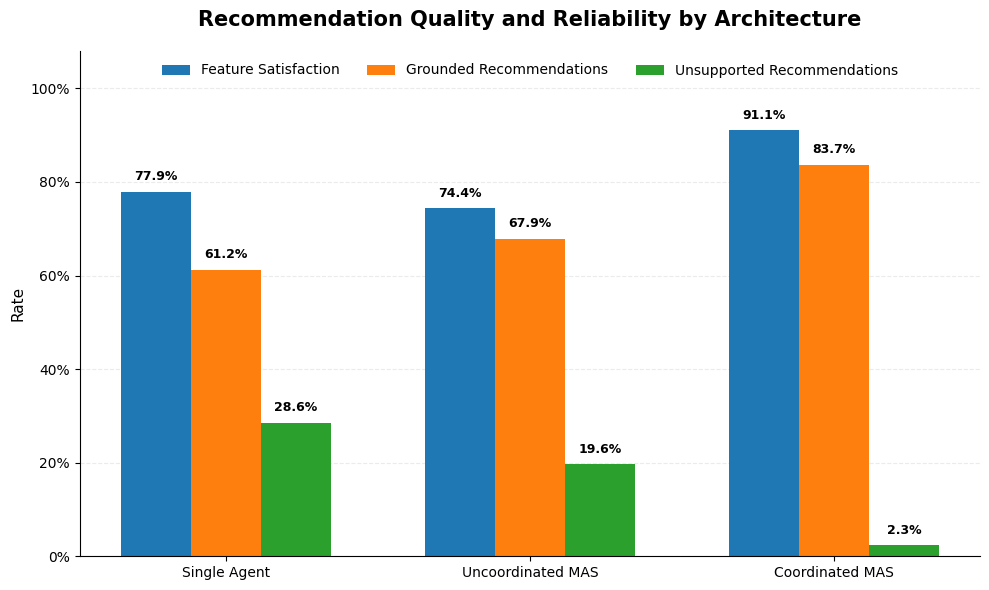

In [ ]:

metrics = [
    "Feature Satisfaction",
    "Grounded Recommendation Rate",
    "Unsupported Recommendation Rate"
]

labels = [
    "Feature\nSatisfaction",
    "Grounded\nRecommendations",
    "Unsupported\nRecommendations"
]


x = np.arange(
    len(plot_df)
)

width = 0.23


fig, ax = plt.subplots(
    figsize=(10, 6)
)


for i, metric in enumerate(metrics):

    positions = (
        x
        + (i - 1) * width
    )

    bars = ax.bar(
        positions,
        plot_df[metric],
        width,
        label=labels[i].replace(
            "\n",
            " "
        )
    )


    for bar, value in zip(
        bars,
        plot_df[metric]
    ):

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,

            value + 0.018,

            f"{value:.1%}",

            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )


ax.set_title(
    "Recommendation Quality and Reliability by Architecture",
    fontsize=15,
    fontweight="bold",
    pad=18
)


ax.set_ylabel(
    "Rate",
    fontsize=11
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    plot_df[
        "Architecture"
    ]
)


ax.set_ylim(
    0,
    1.08
)


ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=1
    )
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(
    True
)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center"
)


plt.tight_layout()


plt.savefig(
    FIGURES_FOLDER
    / "01_recommendation_quality.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

FIG 2 PRECISION@5 AND RECALL@5

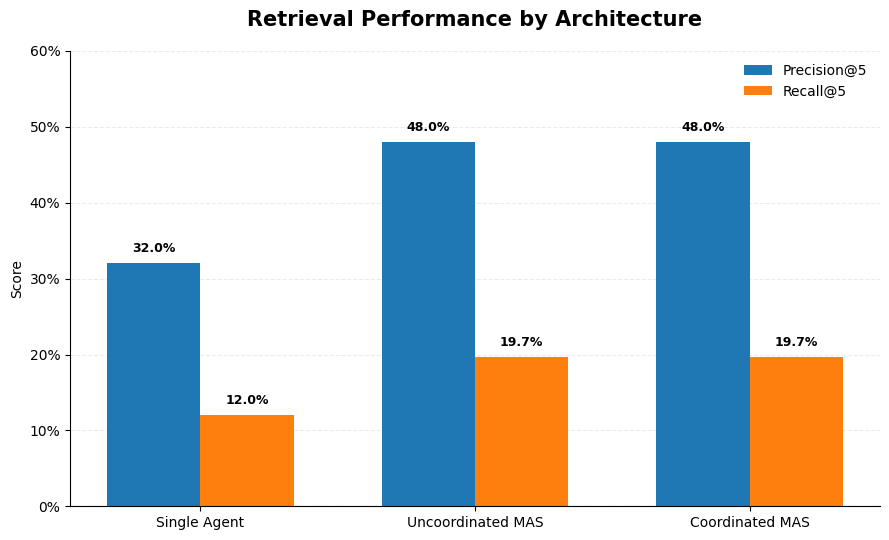

In [ ]:


x = np.arange(
    len(plot_df)
)

width = 0.34


fig, ax = plt.subplots(
    figsize=(9, 5.5)
)


precision_bars = ax.bar(
    x - width / 2,
    plot_df["Precision@5"],
    width,
    label="Precision@5"
)


recall_bars = ax.bar(
    x + width / 2,
    plot_df["Recall@5"],
    width,
    label="Recall@5"
)


for bars in [
    precision_bars,
    recall_bars
]:

    for bar in bars:

        value = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,

            value + 0.015,

            f"{value:.1%}",

            ha="center",
            fontweight="bold",
            fontsize=9
        )


ax.set_title(
    "Retrieval Performance by Architecture",
    fontsize=15,
    fontweight="bold",
    pad=18
)


ax.set_ylabel(
    "Score"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    plot_df["Architecture"]
)


ax.set_ylim(
    0,
    0.60
)


ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=1
    )
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


ax.legend(
    frameon=False
)


plt.tight_layout()


plt.savefig(
    FIGURES_FOLDER
    / "02_precision_recall.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

Coordination did not improve Precision@5/Recall@5 relative to the uncoordinated MAS.

ABESTENTION VS COVERAGE

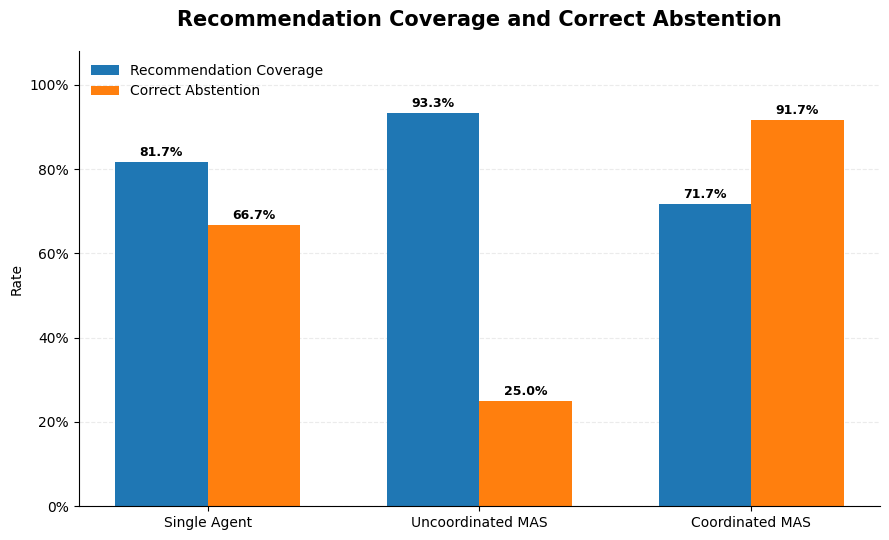

In [ ]:


x = np.arange(
    len(plot_df)
)

width = 0.34


fig, ax = plt.subplots(
    figsize=(9, 5.5)
)


coverage_bars = ax.bar(
    x - width / 2,
    plot_df[
        "Recommendation Coverage"
    ],
    width,
    label="Recommendation Coverage"
)


abstention_bars = ax.bar(
    x + width / 2,
    plot_df[
        "Correct Abstention Rate"
    ],
    width,
    label="Correct Abstention"
)


for bars in [
    coverage_bars,
    abstention_bars
]:

    for bar in bars:

        value = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,

            value + 0.015,

            f"{value:.1%}",

            ha="center",
            fontsize=9,
            fontweight="bold"
        )


ax.set_title(
    "Recommendation Coverage and Correct Abstention",
    fontsize=15,
    fontweight="bold",
    pad=18
)


ax.set_ylabel(
    "Rate"
)


ax.set_xticks(x)

ax.set_xticklabels(
    plot_df["Architecture"]
)


ax.set_ylim(
    0,
    1.08
)


ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=1
    )
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


ax.legend(
    frameon=False
)


plt.tight_layout()


plt.savefig(
    FIGURES_FOLDER
    / "03_coverage_abstention.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

COMPUTATIONAL EFFIECIENCY

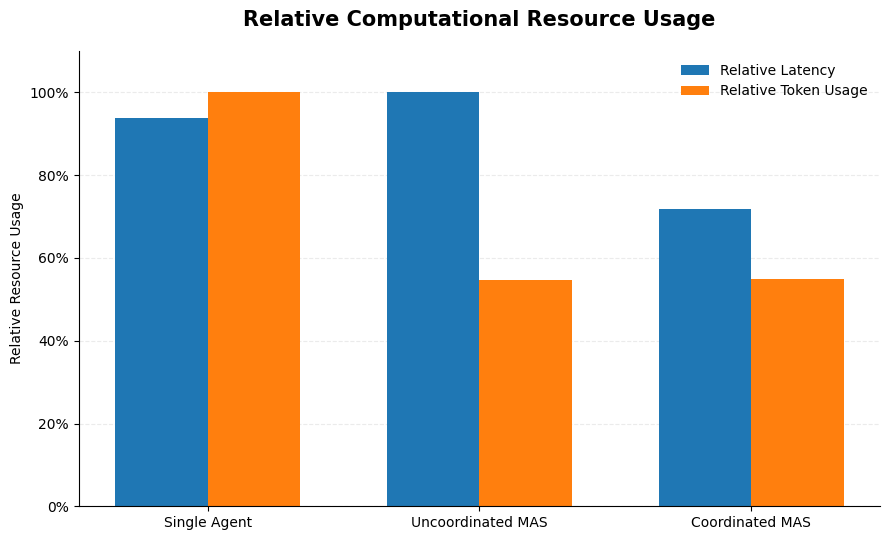

In [ ]:

efficiency_df = (
    plot_df[
        [
            "Architecture",
            "Mean Latency (s)",
            "Mean Tokens"
        ]
    ]
    .copy()
)


efficiency_df[
    "Relative Latency"
] = (
    efficiency_df[
        "Mean Latency (s)"
    ]
    / efficiency_df[
        "Mean Latency (s)"
    ].max()
)


efficiency_df[
    "Relative Token Usage"
] = (
    efficiency_df[
        "Mean Tokens"
    ]
    / efficiency_df[
        "Mean Tokens"
    ].max()
)


x = np.arange(
    len(efficiency_df)
)

width = 0.34


fig, ax = plt.subplots(
    figsize=(9, 5.5)
)


latency_bars = ax.bar(
    x - width / 2,
    efficiency_df[
        "Relative Latency"
    ],
    width,
    label="Relative Latency"
)


token_bars = ax.bar(
    x + width / 2,
    efficiency_df[
        "Relative Token Usage"
    ],
    width,
    label="Relative Token Usage"
)


ax.set_title(
    "Relative Computational Resource Usage",
    fontsize=15,
    fontweight="bold",
    pad=18
)


ax.set_ylabel(
    "Relative Resource Usage"
)


ax.set_xticks(x)

ax.set_xticklabels(
    efficiency_df[
        "Architecture"
    ]
)


ax.set_ylim(
    0,
    1.10
)


ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=1
    )
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


ax.legend(
    frameon=False
)


plt.tight_layout()


plt.savefig(
    FIGURES_FOLDER
    / "04_computational_efficiency.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:


from pathlib import Path
import pandas as pd


print("=" * 70)
print("FINAL EXPERIMENT AUDIT")
print("=" * 70)


# -----------------------------------------------------
# 1. MASTER RESULTS
# -----------------------------------------------------

print("\n[1] MASTER RESULTS")

print(
    "Architectures:",
    final_master_table["Architecture"].tolist()
)

print(
    "Number of architectures:",
    len(final_master_table)
)


# -----------------------------------------------------
# 2. QUERY-LEVEL DATA
# -----------------------------------------------------

print("\n[2] QUERY-LEVEL EVALUATION")

print(
    "Total rows:",
    len(quality)
)

print(
    "Unique test queries:",
    quality["test_id"].nunique()
)

print("\nRows per architecture:")

print(
    quality["system"].value_counts()
)


# -----------------------------------------------------
# 3. TEST CATEGORIES
# -----------------------------------------------------

print("\n[3] TEST CATEGORIES")

print(
    quality["category"].value_counts()
)


# -----------------------------------------------------
# 4. EXPECTED OUTCOMES
# -----------------------------------------------------

print("\n[4] EXPECTED OUTCOMES")

print(
    quality.groupby(
        "system"
    )[
        "expected_outcome"
    ].value_counts()
)


# -----------------------------------------------------
# 5. STATISTICAL TESTS
# -----------------------------------------------------

print("\n[5] STATISTICAL TESTS")

print(
    "Total statistical comparisons:",
    len(final_stats_table)
)

print(
    final_stats_table[
        "test_type"
    ].value_counts()
)


# -----------------------------------------------------
# 6. EFFECT SIZES
# -----------------------------------------------------

print("\n[6] EFFECT SIZES")

print(
    "Effect-size comparisons:",
    len(effect_size_df)
)

print(
    effect_size_df[
        [
            "metric",
            "system_a",
            "rank_biserial_r",
            "magnitude"
        ]
    ]
)


# -----------------------------------------------------
# 7. PRECISION / RECALL
# -----------------------------------------------------

print("\n[7] PRECISION / RECALL")

print(
    final_master_table[
        [
            "Architecture",
            "Precision@5",
            "Recall@5"
        ]
    ]
)


# -----------------------------------------------------
# 8. RELIABILITY
# -----------------------------------------------------

print("\n[8] RELIABILITY")

print(
    final_master_table[
        [
            "Architecture",
            "Grounded Recommendation Rate",
            "Unsupported Recommendation Rate",
            "Correct Abstention Rate"
        ]
    ]
)


# -----------------------------------------------------
# 9. COMPUTATIONAL EFFICIENCY
# -----------------------------------------------------

print("\n[9] COMPUTATIONAL EFFICIENCY")

print(
    final_master_table[
        [
            "Architecture",
            "Mean Latency (s)",
            "Mean Tokens",
            "Mean Cost (USD)"
        ]
    ]
)


# -----------------------------------------------------
# 10. CHECK IMPORTANT FILES
# -----------------------------------------------------

print("\n[10] SAVED FILES")

required_files = [

    "FINAL_MASTER_RESULTS.csv",
    "FINAL_STATISTICAL_SUMMARY.csv",
    "FINAL_EFFECT_SIZES.csv"
]


for filename in required_files:

    path = (
        FINAL_FOLDER
        / filename
    )

    print(
        f"{filename}:",
        "FOUND" if path.exists() else "MISSING"
    )


# -----------------------------------------------------
# FINAL
# -----------------------------------------------------

print("\n" + "=" * 70)
print("AUDIT COMPLETE")
print("=" * 70)

FINAL EXPERIMENT AUDIT

[1] MASTER RESULTS
Architectures: ['Single Agent', 'Uncoordinated MAS', 'Coordinated MAS']
Number of architectures: 3

[2] QUERY-LEVEL EVALUATION
Total rows: 180
Unique test queries: 60

Rows per architecture:
system
Single Agent                        60
Multi-Agent Without Coordination    60
Coordinated Multi-Agent             60
Name: count, dtype: int64

[3] TEST CATEGORIES
category
Brand + Feature      24
Multiple Features    24
Feature Only         24
No Match             21
Budget               21
Unsupported          18
Complex              18
Brand Only           15
Ambiguous            15
Name: count, dtype: int64

[4] EXPECTED OUTCOMES
system                            expected_outcome
Coordinated Multi-Agent           match               48
                                  no_match            12
Multi-Agent Without Coordination  match               48
                                  no_match            12
Single Agent                      match   

In [ ]:


print("1. Architectures:", quality["system"].nunique())
print("2. Unique queries:", quality["test_id"].nunique())
print("3. Total evaluations:", len(quality))

print("\n4. Categories per unique query:")
print(
    quality[
        ["test_id", "category"]
    ]
    .drop_duplicates()
    ["category"]
    .value_counts()
)

print("\n5. Expected outcomes per unique query:")
print(
    quality[
        ["test_id", "expected_outcome"]
    ]
    .drop_duplicates()
    ["expected_outcome"]
    .value_counts()
)

print("\n6. Statistical tests:", len(final_stats_table))
print("7. Effect sizes:", len(effect_size_df))

print("\n8. Required files:")
for filename in [
    "FINAL_MASTER_RESULTS.csv",
    "FINAL_STATISTICAL_SUMMARY.csv",
    "FINAL_EFFECT_SIZES.csv"
]:
    print(
        filename,
        "->",
        (FINAL_FOLDER / filename).exists()
    )

1. Architectures: 3
2. Unique queries: 60
3. Total evaluations: 180

4. Categories per unique query:
category
Brand + Feature      8
Multiple Features    8
Feature Only         8
No Match             7
Budget               7
Unsupported          6
Complex              6
Brand Only           5
Ambiguous            5
Name: count, dtype: int64

5. Expected outcomes per unique query:
expected_outcome
match       48
no_match    12
Name: count, dtype: int64

6. Statistical tests: 12
7. Effect sizes: 6

8. Required files:
FINAL_MASTER_RESULTS.csv -> True
FINAL_STATISTICAL_SUMMARY.csv -> True
FINAL_EFFECT_SIZES.csv -> True


In [56]:
print("Architectures:", quality["system"].nunique())
print("Unique queries:", quality["test_id"].nunique())
print("Total evaluations:", len(quality))

print("\nUnique-query categories:")
print(
    quality[["test_id", "category"]]
    .drop_duplicates()
    ["category"]
    .value_counts()
)

print("\nExpected outcomes:")
print(
    quality[["test_id", "expected_outcome"]]
    .drop_duplicates()
    ["expected_outcome"]
    .value_counts()
)

print("\nStatistical tests:", len(final_stats_table))
print("Effect sizes:", len(effect_size_df))

print("\nFiles:")
for f in [
    "FINAL_MASTER_RESULTS.csv",
    "FINAL_STATISTICAL_SUMMARY.csv",
    "FINAL_EFFECT_SIZES.csv"
]:
    print(f, "->", (FINAL_FOLDER / f).exists())

Architectures: 3
Unique queries: 60
Total evaluations: 180

Unique-query categories:
category
Brand + Feature      8
Multiple Features    8
Feature Only         8
No Match             7
Budget               7
Unsupported          6
Complex              6
Brand Only           5
Ambiguous            5
Name: count, dtype: int64

Expected outcomes:
expected_outcome
match       48
no_match    12
Name: count, dtype: int64

Statistical tests: 12
Effect sizes: 6

Files:
FINAL_MASTER_RESULTS.csv -> True
FINAL_STATISTICAL_SUMMARY.csv -> True
FINAL_EFFECT_SIZES.csv -> True


TASK COMPLETION RATE

In [ ]:

quality["successful_task"] = False




match_mask = (
    quality["expected_outcome"]
    == "match"
)

quality.loc[
    match_mask,
    "successful_task"
] = (

    quality.loc[
        match_mask,
        "has_recommendation"
    ].astype(bool)

    &

    quality.loc[
        match_mask,
        "support_level"
    ].isin(
        [
            "grounded",
            "partial"
        ]
    )
)




no_match_mask = (
    quality["expected_outcome"]
    == "no_match"
)

quality.loc[
    no_match_mask,
    "successful_task"
] = (
    quality.loc[
        no_match_mask,
        "correct_abstention"
    ].astype(bool)
)


task_completion_df = (

    quality

    .groupby(
        "system"
    )

    .agg(

        successful_tasks=(
            "successful_task",
            "sum"
        ),

        total_tasks=(
            "test_id",
            "count"
        )
    )

    .reset_index()
)


task_completion_df[
    "task_completion_rate"
] = (

    task_completion_df[
        "successful_tasks"
    ]

    / task_completion_df[
        "total_tasks"
    ]
)


display(
    task_completion_df
)


task_completion_df.to_csv(
    FINAL_FOLDER
    / "task_completion_rate.csv",
    index=False
)

print(
    "Saved task_completion_rate.csv"
)

,system,successful_tasks,total_tasks,task_completion_rate
0,Coordinated Multi-Agent,52,60,0.866667
1,Multi-Agent Without Coordination,46,60,0.766667
2,Single Agent,42,60,0.700000


Saved task_completion_rate.csv


                             system  successful_tasks  total_tasks  \
0           Coordinated Multi-Agent                52           60   
1  Multi-Agent Without Coordination                46           60   
2                      Single Agent                42           60   

   task_completion_rate  
0              0.866667  
1              0.766667  
2              0.700000  


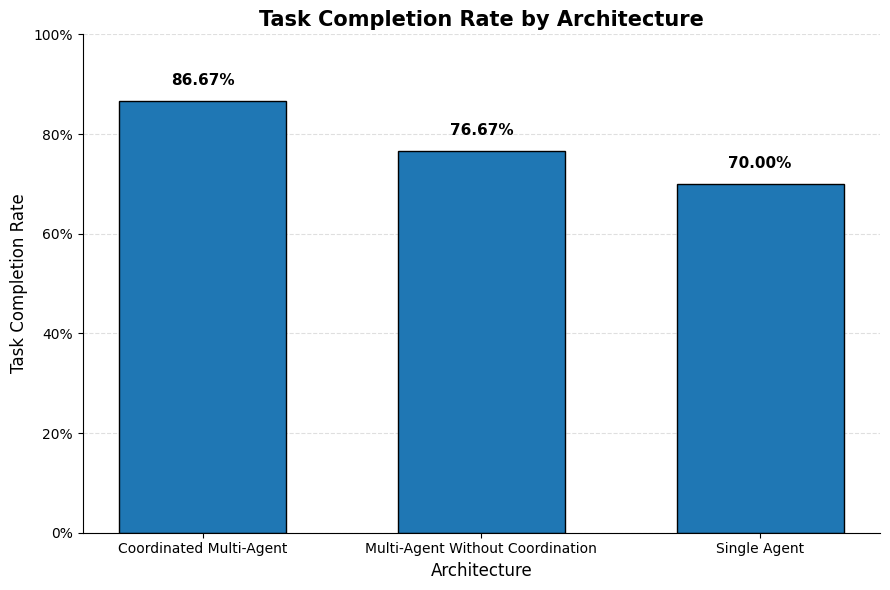

Saved 13_task_completion_rate.png


In [ ]:


import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Use dataframe directly
plot_df = task_completion_df.copy()

print(plot_df)

# Create graph
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    plot_df["system"],
    plot_df["task_completion_rate"],
    width=0.6,
    edgecolor="black"
)

# Y-axis
ax.set_ylim(0, 1)

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

# Labels
ax.set_title(
    "Task Completion Rate by Architecture",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Architecture",
    fontsize=12
)

ax.set_ylabel(
    "Task Completion Rate",
    fontsize=12
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.set_axisbelow(True)

# Values above bars
for bar, value in zip(
    bars,
    plot_df["task_completion_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.025,
        f"{value:.2%}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save
plt.savefig(
    FINAL_FOLDER / "13_task_completion_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved 13_task_completion_rate.png")

COORDINATION EFFICIENCY ANALYSIS

In [ ]:


uncoord = final_master_table[
    final_master_table[
        "Architecture"
    ]
    == "Uncoordinated MAS"
].iloc[0]


coord = final_master_table[
    final_master_table[
        "Architecture"
    ]
    == "Coordinated MAS"
].iloc[0]


coordination_efficiency_df = pd.DataFrame({

    "Metric": [

        "Feature Satisfaction",

        "Grounded Recommendation Rate",

        "Unsupported Recommendation Rate",

        "Correct Abstention Rate",

        "Recommendation Coverage",

        "Mean Latency (s)",

        "Mean Tokens",

        "Mean Cost (USD)"
    ],

    "Uncoordinated MAS": [

        uncoord[
            "Feature Satisfaction"
        ],

        uncoord[
            "Grounded Recommendation Rate"
        ],

        uncoord[
            "Unsupported Recommendation Rate"
        ],

        uncoord[
            "Correct Abstention Rate"
        ],

        uncoord[
            "Recommendation Coverage"
        ],

        uncoord[
            "Mean Latency (s)"
        ],

        uncoord[
            "Mean Tokens"
        ],

        uncoord[
            "Mean Cost (USD)"
        ]
    ],

    "Coordinated MAS": [

        coord[
            "Feature Satisfaction"
        ],

        coord[
            "Grounded Recommendation Rate"
        ],

        coord[
            "Unsupported Recommendation Rate"
        ],

        coord[
            "Correct Abstention Rate"
        ],

        coord[
            "Recommendation Coverage"
        ],

        coord[
            "Mean Latency (s)"
        ],

        coord[
            "Mean Tokens"
        ],

        coord[
            "Mean Cost (USD)"
        ]
    ]
})


coordination_efficiency_df[
    "Relative Change (%)"
] = (

    (
        coordination_efficiency_df[
            "Coordinated MAS"
        ]

        -

        coordination_efficiency_df[
            "Uncoordinated MAS"
        ]
    )

    /

    coordination_efficiency_df[
        "Uncoordinated MAS"
    ]

    * 100
)


coordination_efficiency_df[
    "Relative Change (%)"
] = (
    coordination_efficiency_df[
        "Relative Change (%)"
    ]
    .round(2)
)


display(
    coordination_efficiency_df
)


coordination_efficiency_df.to_csv(
    FINAL_FOLDER
    / "coordination_efficiency_analysis.csv",
    index=False
)

print(
    "Saved coordination_efficiency_analysis.csv"
)

,Metric,Uncoordinated MAS,Coordinated MAS,Relative Change (%)
0,Feature Satisfaction,0.744000,0.910900,22.43
1,Grounded Recommendation Rate,0.678600,0.837200,23.37
2,Unsupported Recommendation Rate,0.196400,0.023300,-88.14
3,Correct Abstention Rate,0.250000,0.916700,266.68
4,Recommendation Coverage,0.933300,0.716700,-23.21
5,Mean Latency (s),6.677000,4.790000,-28.26
6,Mean Tokens,1847.800000,1851.400000,0.19
7,Mean Cost (USD),0.000365,0.000368,0.82


Saved coordination_efficiency_analysis.csv


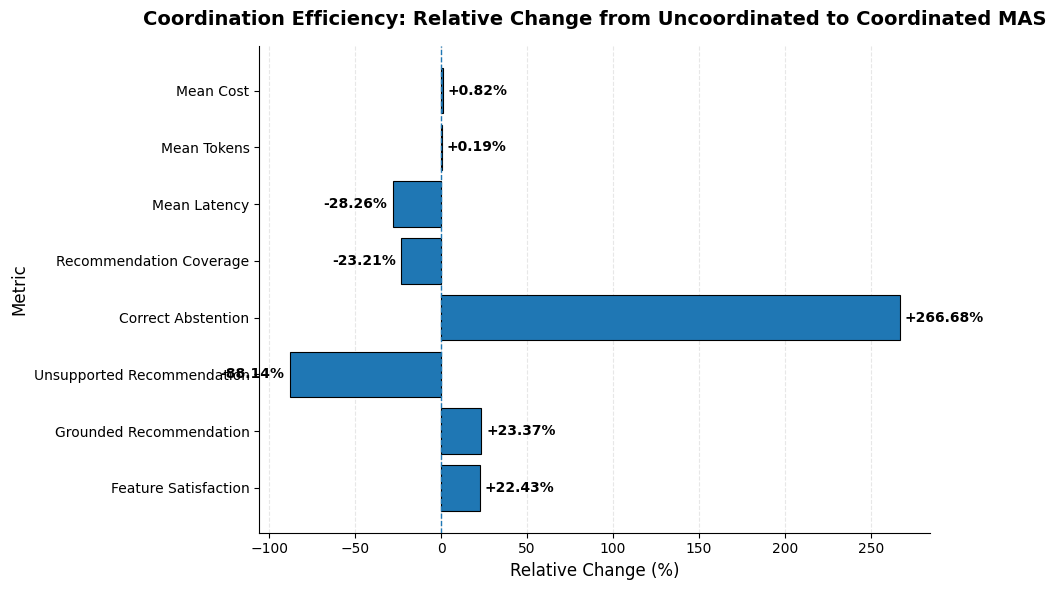

Saved 14_coordination_efficiency.png


In [ ]:


import matplotlib.pyplot as plt



plot_df = coordination_efficiency_df.copy()


label_map = {
    "Feature Satisfaction": "Feature Satisfaction",
    "Grounded Recommendation Rate": "Grounded Recommendation",
    "Unsupported Recommendation Rate": "Unsupported Recommendation",
    "Correct Abstention Rate": "Correct Abstention",
    "Recommendation Coverage": "Recommendation Coverage",
    "Mean Latency (s)": "Mean Latency",
    "Mean Tokens": "Mean Tokens",
    "Mean Cost (USD)": "Mean Cost"
}

plot_df["Display Metric"] = (
    plot_df["Metric"]
    .map(label_map)
)


fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_df["Display Metric"],
    plot_df["Relative Change (%)"],
    edgecolor="black",
    linewidth=0.8
)


ax.axvline(
    x=0,
    linewidth=1,
    linestyle="--"
)

# -----------------------------------------------------
# Titles and labels
# -----------------------------------------------------

ax.set_title(
    "Coordination Efficiency: Relative Change from "
    "Uncoordinated to Coordinated MAS",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Relative Change (%)",
    fontsize=12
)

ax.set_ylabel(
    "Metric",
    fontsize=12
)

# -----------------------------------------------------
# Grid
# -----------------------------------------------------

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# -----------------------------------------------------
# Add percentage values
# -----------------------------------------------------

for bar, value in zip(
    bars,
    plot_df["Relative Change (%)"]
):

    y_position = (
        bar.get_y()
        + bar.get_height() / 2
    )

    if value >= 0:

        ax.text(
            value + 3,
            y_position,
            f"+{value:.2f}%",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold"
        )

    else:

        ax.text(
            value - 3,
            y_position,
            f"{value:.2f}%",
            va="center",
            ha="right",
            fontsize=10,
            fontweight="bold"
        )

# -----------------------------------------------------
# Clean appearance
# -----------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# -----------------------------------------------------
# Save graph
# -----------------------------------------------------

plt.savefig(
    FINAL_FOLDER / "14_coordination_efficiency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved 14_coordination_efficiency.png"
)

COMMUNINCATION OVERHEAD PROXY

In [ ]:


overhead_proxy_df = pd.DataFrame({

    "Metric": [
        "Mean Latency (s)",
        "Mean Tokens",
        "Mean Cost (USD)"
    ],

    "Uncoordinated MAS": [
        uncoord[
            "Mean Latency (s)"
        ],

        uncoord[
            "Mean Tokens"
        ],

        uncoord[
            "Mean Cost (USD)"
        ]
    ],

    "Coordinated MAS": [
        coord[
            "Mean Latency (s)"
        ],

        coord[
            "Mean Tokens"
        ],

        coord[
            "Mean Cost (USD)"
        ]
    ]
})


overhead_proxy_df[
    "Absolute Difference"
] = (

    overhead_proxy_df[
        "Coordinated MAS"
    ]

    -

    overhead_proxy_df[
        "Uncoordinated MAS"
    ]
)


overhead_proxy_df[
    "Relative Difference (%)"
] = (

    overhead_proxy_df[
        "Absolute Difference"
    ]

    /

    overhead_proxy_df[
        "Uncoordinated MAS"
    ]

    * 100
)


overhead_proxy_df[
    "Relative Difference (%)"
] = (
    overhead_proxy_df[
        "Relative Difference (%)"
    ]
    .round(2)
)


display(
    overhead_proxy_df
)


overhead_proxy_df.to_csv(
    FINAL_FOLDER
    / "coordination_overhead_proxy.csv",
    index=False
)

print(
    "Saved coordination_overhead_proxy.csv"
)

,Metric,Uncoordinated MAS,Coordinated MAS,Absolute Difference,Relative Difference (%)
0,Mean Latency (s),6.677000,4.790000,-1.887000,-28.26
1,Mean Tokens,1847.800000,1851.400000,3.600000,0.19
2,Mean Cost (USD),0.000365,0.000368,0.000003,0.82


Saved coordination_overhead_proxy.csv


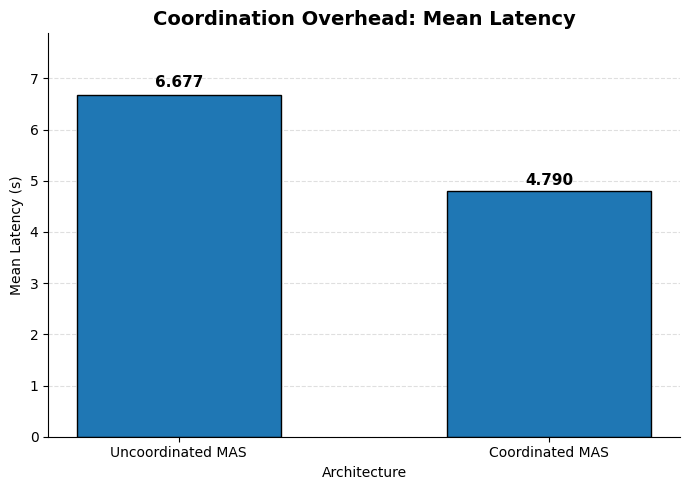

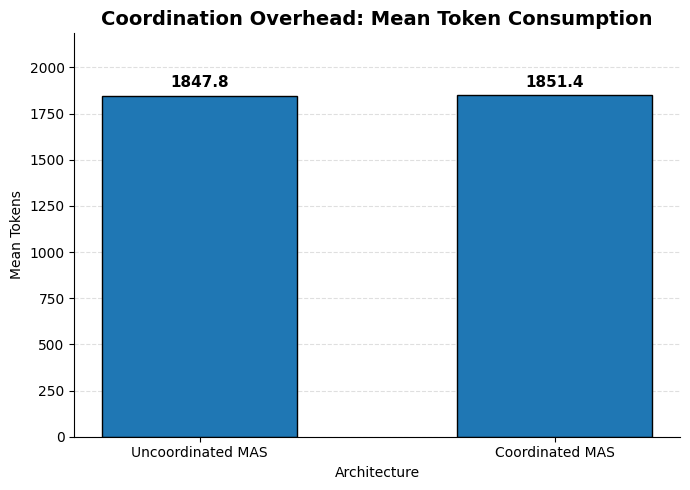

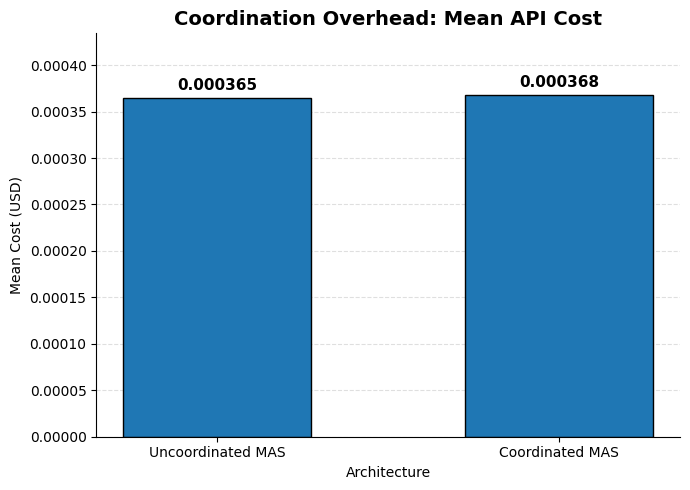

In [71]:
import matplotlib.pyplot as plt

systems = [
    "Uncoordinated MAS",
    "Coordinated MAS"
]

metrics = [
    ("Mean Latency (s)", "Mean Latency (s)", "Coordination Overhead: Mean Latency", "14_coordination_overhead_latency.png"),
    ("Mean Tokens", "Mean Tokens", "Coordination Overhead: Mean Token Consumption", "15_coordination_overhead_tokens.png"),
    ("Mean Cost (USD)", "Mean Cost (USD)", "Coordination Overhead: Mean API Cost", "16_coordination_overhead_cost.png")
]

for metric, ylabel, title, filename in metrics:

    row = overhead_proxy_df[
        overhead_proxy_df["Metric"] == metric
    ].iloc[0]

    values = [
        row["Uncoordinated MAS"],
        row["Coordinated MAS"]
    ]

    fig, ax = plt.subplots(figsize=(7, 5))

    bars = ax.bar(
        systems,
        values,
        width=0.55,
        edgecolor="black"
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Architecture")
    ax.set_ylabel(ylabel)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    ax.set_axisbelow(True)

    for bar, value in zip(bars, values):

        if metric == "Mean Cost (USD)":
            label = f"{value:.6f}"
        elif metric == "Mean Tokens":
            label = f"{value:.1f}"
        else:
            label = f"{value:.3f}"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.015,
            label,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax.set_ylim(
        0,
        max(values) * 1.18
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    plt.savefig(
        FINAL_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

CONFILICT RESOLTUION EFFECTIVENESS

In [ ]:


conflict_resolution_df = pd.DataFrame({

    "Metric": [

        "Unsupported Recommendation Rate",

        "Correct Abstention Rate"
    ],

    "Uncoordinated MAS": [

        uncoord[
            "Unsupported Recommendation Rate"
        ],

        uncoord[
            "Correct Abstention Rate"
        ]
    ],

    "Coordinated MAS": [

        coord[
            "Unsupported Recommendation Rate"
        ],

        coord[
            "Correct Abstention Rate"
        ]
    ]
})


conflict_resolution_df[
    "Absolute Change"
] = (

    conflict_resolution_df[
        "Coordinated MAS"
    ]

    -

    conflict_resolution_df[
        "Uncoordinated MAS"
    ]
)


display(
    conflict_resolution_df
)


conflict_resolution_df.to_csv(
    FINAL_FOLDER
    / "conflict_resolution_effectiveness.csv",
    index=False
)

print(
    "Saved conflict_resolution_effectiveness.csv"
)

,Metric,Uncoordinated MAS,Coordinated MAS,Absolute Change
0,Unsupported Recommendation Rate,0.1964,0.0233,-0.1731
1,Correct Abstention Rate,0.2500,0.9167,0.6667


Saved conflict_resolution_effectiveness.csv


CLEAN SCALABILITY SUMMARY

In [ ]:


no_coord_scalability = pd.read_csv(
    FINAL_FOLDER
    / "no_coord_scalability.csv"
)

coord_scalability = pd.read_csv(
    FINAL_FOLDER
    / "coordinated_scalability.csv"
)


scalability_all = pd.concat(
    [
        no_coord_scalability,
        coord_scalability
    ],
    ignore_index=True
)


final_scalability_summary = (

    scalability_all

    .groupby(
        [
            "system",
            "retrieval_k"
        ],
        as_index=False
    )

    .agg(

        mean_latency=(
            "latency",
            "mean"
        ),

        std_latency=(
            "latency",
            "std"
        ),

        mean_tokens=(
            "tokens",
            "mean"
        ),

        std_tokens=(
            "tokens",
            "std"
        )
    )
)


display(
    final_scalability_summary
)


final_scalability_summary.to_csv(
    FINAL_FOLDER
    / "final_scalability_summary.csv",
    index=False
)

print(
    "Saved final_scalability_summary.csv"
)

,system,retrieval_k,mean_latency,std_latency,mean_tokens,std_tokens
0,Coordinated Multi-Agent,5,4.131550,0.603951,1650.625,129.525439
1,Coordinated Multi-Agent,10,4.080650,0.395685,1638.500,131.657564
2,Coordinated Multi-Agent,20,6.258025,1.796878,1969.500,393.117939
3,Coordinated Multi-Agent,30,6.496462,2.823595,2015.375,451.632258
4,Multi-Agent Without Coordination,5,3.987600,0.647407,1654.250,124.983142
5,Multi-Agent Without Coordination,10,3.497663,0.268361,1644.125,134.728762
6,Multi-Agent Without Coordination,20,5.630175,3.101755,2017.250,481.862088
7,Multi-Agent Without Coordination,30,5.169837,1.992185,2000.750,431.849097


Saved final_scalability_summary.csv


IMPLEMENTATION-FEEDBACK EVIDENCE TABLE

In [ ]:


implementation_feedback_df = pd.DataFrame({

    "Marker Concern": [

        "Task completion rate",

        "Coordination efficiency",

        "Communication overhead",

        "Conflict resolution",

        "Scalability",

        "Recommendation accuracy / quality",

        "Resource utilisation",

        "System reliability"
    ],

    "Implementation Evidence": [

        "Derived successful task completion across match and no-match benchmark queries",

        "Direct Coordinated MAS vs Uncoordinated MAS comparison across quality and efficiency metrics",

        "Indirect proxy using end-to-end latency, token usage and API cost",

        "Verifier-based filtering and abstention; evaluated through unsupported recommendation and correct abstention rates",

        "Retrieval workload tested at k = 5, 10, 20 and 30",

        "Precision@5, Recall@5 and feature satisfaction",

        "Latency, token consumption and estimated API cost",

        "Grounded recommendation rate, unsupported recommendation rate and correct abstention"
    ],

    "Status": [

        "Addressed",

        "Addressed",

        "Partially addressed - indirect proxy",

        "Addressed",

        "Addressed within retrieval workload scope",

        "Addressed",

        "Addressed",

        "Addressed"
    ]
})


display(
    implementation_feedback_df
)


implementation_feedback_df.to_csv(
    FINAL_FOLDER
    / "implementation_feedback_evidence.csv",
    index=False
)

print(
    "Saved implementation_feedback_evidence.csv"
)

,Marker Concern,Implementation Evidence,Status
0,Task completion rate,Derived successful task completion across matc...,Addressed
1,Coordination efficiency,Direct Coordinated MAS vs Uncoordinated MAS co...,Addressed
2,Communication overhead,"Indirect proxy using end-to-end latency, token...",Partially addressed - indirect proxy
3,Conflict resolution,Verifier-based filtering and abstention; evalu...,Addressed
4,Scalability,"Retrieval workload tested at k = 5, 10, 20 and 30",Addressed within retrieval workload scope
5,Recommendation accuracy / quality,"Precision@5, Recall@5 and feature satisfaction",Addressed
6,Resource utilisation,"Latency, token consumption and estimated API cost",Addressed
7,System reliability,"Grounded recommendation rate, unsupported reco...",Addressed


Saved implementation_feedback_evidence.csv


In [ ]:

from pathlib import Path
from datetime import datetime
import sys
import platform

PROJECT_ROOT = Path("..").resolve()

info_file = (
    PROJECT_ROOT
    / "FINAL_EXPERIMENT_INFO.txt"
)

info = f"""
MULTI-AGENT COORDINATION FOR E-COMMERCE
FINAL EXPERIMENT SNAPSHOT

Frozen on:
{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

Python version:
{sys.version}

Operating system:
{platform.platform()}

Project root:
{PROJECT_ROOT}

FINAL EXPERIMENT DESIGN
-----------------------
Architectures: 3

1. Single Agent
2. Multi-Agent Without Coordination
3. Coordinated Multi-Agent

Unique benchmark queries: 60
Total architecture evaluations: 180

Expected outcomes:
Match: 48
No Match: 12

Query categories: 9

FINAL EVALUATION INCLUDES
-------------------------
Precision@5
Recall@5
Feature Satisfaction
Grounded Recommendation Rate
Unsupported Recommendation Rate
Correct Abstention Rate
Recommendation Coverage
Task Completion Rate
Latency
Token Consumption
Estimated API Cost
Coordination Efficiency
Conflict Resolution Effectiveness
Scalability
Statistical Significance Tests
Effect Sizes

IMPORTANT
---------
This snapshot represents the frozen final experimental implementation.

Final experiments should not be rerun unless an implementation
or evaluation error is identified.

LLM-generated outputs may vary between executions.
"""

info_file.write_text(
    info,
    encoding="utf-8"
)

print("Created:")
print(info_file)

Created:
C:\Users\srush\Desktop\Multi agent coordination\FINAL_EXPERIMENT_INFO.txt
